# Does less-specific conditioning improve cosmology recovery?
## tl;dr
This notebook reviews **conditional UNet-u128**, not DiT: six-parameter continuous (original baseline), two-parameter continuous, and 36 coarse classes.

**Status (supplied Slurm accounting, 3 October 2026):** all six jobs are COMPLETED: training 62232389 / 62232393, sampling 62232390 / 62232394, evaluation 62232391 / 62232395. Completion is not taken as proof of results: the Data section below checks that every expected sample NPZ, evaluation CSV and metadata file exists and passes validation before any result is shown.

Read sections in order. Missing result files are reported as unavailable, never as zero. This notebook reads saved CSVs and saved sample NPZs only: no training, sampling, probe inference or downloads. Its only writes are figures and small summary CSVs in a fresh timestamped folder under `results/nf_conditional_omsig_*/figures/`.

## Context & Methods
### What did we change?
| Experiment | What the model is told | What it tests |
|---|---|---|
| Six-parameter continuous | Exact six CAMELS parameters | Original baseline from conditional_unet_low_n_bias_diagnostics |
| Continuous two-parameter | Exact normalized Ωm and σ8 | Can the model respond to two continuous parameters? |
| 36-class | One of 6 Ωm bins × 6 σ8 bins | Does pooling nearby cosmologies under one label help? |

Both sweep N = 64, 256, 1,024, 4,096, 32,768 and target 200,000 updates. The preparer asserts the same training selections as the six-parameter full sweep at each N. Continuous uses UNet2DConditionModel; class uses UNet2DModel with class embeddings: **this is not solely a numerical change of labels; the conditioning implementation differs too.**

Source: `scripts/prepare_nf_conditional_label_sweep_configs.py` and the two `evaluate_nf_conditional_omsig_*.sbatch` launchers. These describe intended recipes, not independent verification of every remote checkpoint.

### What counts as a good result?
* **Bias:** for each held-out cosmology, median probe recovery minus its true parameter; summarize over 32 cosmologies. Negative Ωm bias means under-recovery. Zero median can hide opposite errors, so also show median absolute error.
* **68% recovery coverage:** fraction of the 32 true values inside the 16th–84th percentile range of probe outputs on generated maps. Around 22/32 is roughly 68%; one cosmology changes coverage by 3.125 percentage points.
* **Interval width:** wider generated distributions can increase coverage without improving accuracy.
* These are **probe-recovery intervals, not Bayesian posterior credible intervals or TARP**. There is only one training seed per model; these plots do not quantify training-seed uncertainty.

### Key assumptions and class-conditioning caveat
The evaluation requests 64 draws for each simulation 900–931 and reuses the frozen VGG probe. Two cosmologies in the same class receive the **same conditioning label**. Consequently, exact-value recovery is a useful diagnostic but not a demand the class model can satisfy uniquely. Bins span ΔΩm = 0.4/6 and Δσ8 = 0.4/6. Broad within-bin recovery is not automatically failure. No superiority claim should rest on coverage alone.

### Original baseline and comparison scope
Baseline source: `results/nf_conditional_bias_fresh_full_sweep_200k/calibration_vgg/` — the same sweep selected by default in `conditional_unet_low_n_bias_diagnostics.ipynb`.

Compare all three at the **shared N = 64, 256, 1,024, 4,096, 32,768**. The baseline's additional sizes are intentionally excluded from this matched-size view, not missing. Gray triangles mark the six-parameter baseline. Its available results can plot even while the newer sweeps remain pending.

These are original generated-map recovery results, **not Test 4 blends/NNLS or the fixed-64 multiplicity runs**. Class conditioning asks for a bin rather than an exact point; the four unconditioned parameters in the two new variants vary implicitly. The comparison therefore measures different conditioning tasks, not a pure architecture effect.

In [1]:
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Launch from the repository or its notebooks directory; change explicitly if needed.
PROJECT_DIR = next((p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'scripts/prepare_nf_conditional_label_sweep_configs.py').is_file()), Path.cwd())
SIZES = [64, 256, 1024, 4096, 32768]
SWEEPS = {'Six-parameter continuous': 'nf_conditional_bias_fresh_full_sweep_200k',
          'Continuous Ωm–σ8': 'nf_conditional_omsig_continuous_200k',
          '36-class Ωm–σ8': 'nf_conditional_omsig_class36_200k'}
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
print('Reading repository:', PROJECT_DIR)

# Figures: fresh timestamped subfolder in each requested figures directory; never reuse an existing one.
import os, datetime
RUN_STAMP = os.environ.get('REVIEW_RUN_STAMP') or datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
FIG_DIRS = {label: PROJECT_DIR / 'results' / SWEEPS[label] / 'figures' / ('label_sweeps_review_' + RUN_STAMP)
            for label in ['Continuous Ωm–σ8', '36-class Ωm–σ8']}
for d in FIG_DIRS.values():
    d.mkdir(parents=True, exist_ok=False)
    print('Figures ->', d)

def save_figure(fig, name, labels=None):
    """Write PNG+PDF to the figures folder of each listed variant (default: both)."""
    for label in (labels or FIG_DIRS):
        for ext in ('png', 'pdf'):
            fig.savefig(FIG_DIRS[label] / f'{name}.{ext}', dpi=150, bbox_inches='tight')


Reading repository: /home/jiamingp/diffusion_models_repo
Figures -> /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/figures/label_sweeps_review_20261003_141316
Figures -> /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_class36_200k/figures/label_sweeps_review_20261003_141316


## Data
### Job status from supplied Slurm accounting
“COMPLETED” below means Slurm state COMPLETED with exit 0:0, as supplied on 3 October 2026. It is not by itself evidence of results; the next two cells check the actual result files.

In [2]:
status = pd.DataFrame({
 'Variant': ['Continuous Ωm–σ8', '36-class Ωm–σ8'],
 'Training array': ['62232389 COMPLETED', '62232393 COMPLETED'],
 'Sampling array': ['62232390 COMPLETED', '62232394 COMPLETED'],
 'Evaluation': ['62232391 COMPLETED', '62232395 COMPLETED'],
})
display(status)
print('Supplied accounting only; result files are verified below before anything is reported.')


,Variant,Training array,Sampling array,Evaluation
0,Continuous Ωm–σ8,62232389 COMPLETED,62232390 COMPLETED,62232391 COMPLETED
1,36-class Ωm–σ8,62232393 COMPLETED,62232394 COMPLETED,62232395 COMPLETED


Supplied accounting only; result files are verified below before anything is reported.


### Load and validate existing probe outputs
Each accepted group must contain exactly one run and exactly 32 distinct held-out cosmologies, with finite ordered quantiles. CSVs missing metadata are withheld. Source hashes identify precisely which files were read; the metadata below allows inspection of the probe and evaluation recipe. The original six-parameter sweep is included explicitly. Recorded probe settings, draw counts, held-out IDs and requested values must match before recovery curves are overlaid.

In [3]:
frames, inventory, probe_metadata = [], [], {}
required = {'parameter','dataset_size','guidance_label','cfg_dropout','heldout_sim',
            'run_name','theta_in','theta_rec_median','theta_rec_q16','theta_rec_q84','n_samples'}
for label, sweep in SWEEPS.items():
    folder = PROJECT_DIR / 'results' / sweep / 'calibration_vgg'
    path = folder / 'bias_probe_per_cosmology_points.csv'
    meta = folder / 'bias_probe_eval_metadata.json'
    state = 'Available' if path.is_file() and meta.is_file() else 'Unavailable (CSV or metadata missing)'
    inventory.append({'Experiment': label, 'Status': state, 'Source': str(path)})
    if state != 'Available':
        continue
    metadata = json.loads(meta.read_text())
    probe_metadata[label] = metadata
    print(label, '\nMetadata:', json.dumps(metadata, indent=2))
    print('CSV SHA256:', hashlib.sha256(path.read_bytes()).hexdigest())
    df = pd.read_csv(path)
    assert required <= set(df), (path, required - set(df))
    df = df[(df.guidance_label == 'noguidance') & (df.cfg_dropout == 0)
            & df.parameter.isin(['Omega_m', 'sigma_8']) & df.dataset_size.isin(SIZES)].copy()
    for (n, parameter), group in df.groupby(['dataset_size','parameter']):
        assert len(group) == 32 and set(group.heldout_sim.astype(int)) == set(range(900,932)), (label,n,parameter)
        assert group.run_name.nunique() == 1
        assert (group.n_samples == 64).all(), (label,n,parameter,"Expected 64 draws")
        vals = group[['theta_in','theta_rec_median','theta_rec_q16','theta_rec_q84']].to_numpy(float)
        assert np.isfinite(vals).all()
        assert (vals[:,2] <= vals[:,1]).all() and (vals[:,1] <= vals[:,3]).all()
    df['Experiment'], df['Source'] = label, str(path)
    frames.append(df)
display(pd.DataFrame(inventory))
points = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
if points.empty:
    display(Markdown('**No evaluated parameter-recovery results are available at this repository path. Scientific charts below are withheld, not filled with illustrative numbers.**'))

# Compare recorded probe identity/preprocessing, not just CSV column names.
if len(probe_metadata)>1:
    keys = ['encoder_type','encoder_path','vgg_model_path','vgg_weights',
            'vgg_image_size','vgg_pool','vgg_feature_dim','param_names']
    first_label = next(iter(probe_metadata))
    reference = probe_metadata[first_label]
    for label, meta in probe_metadata.items():
        for key in keys:
            assert key in meta and key in reference, ('Missing probe metadata',label,key)
            a,b=meta[key],reference[key]
            if key in ('encoder_path','vgg_model_path'):
                a,b=Path(a),Path(b)
                a=(a if a.is_absolute() else PROJECT_DIR/a).resolve()
                b=(b if b.is_absolute() else PROJECT_DIR/b).resolve()
            assert a==b, ('Probe mismatch: do not overlay',label,first_label,key)
    for (size,param), group in points.groupby(['dataset_size','parameter']):
        truth = group.pivot(index='heldout_sim',columns='Experiment',values='theta_in')
        assert np.allclose(truth.to_numpy(),truth.iloc[:,0].to_numpy()[:,None],atol=1e-7,rtol=0), ('Requested parameters differ',size,param)
    print('Recorded probe settings, 64 draws, held-out IDs and requested values match.')
    print('Historical artifact immutability and full training-recipe equivalence are not established by this check.')


Six-parameter continuous 
Metadata: {
  "encoder_path": "/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_probe/encoder/vgg_mlp_encoder.npz",
  "encoder_type": "vgg",
  "pca_basis_path": "none-vgg",
  "pca_basis_sha256": "none-vgg",
  "pca_rank": 0,
  "pca_explained_variance_sum": 0.0,
  "param_names": [
    "Omega_m",
    "sigma_8",
    "A_SN1",
    "A_AGN1",
    "A_SN2",
    "A_AGN2"
  ],
  "guidance_labels": [
    "noguidance"
  ],
  "vgg_model_path": "/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_probe/encoder/vgg_mlp_encoder.pkl",
  "vgg_weights": "IMAGENET1K_V1",
  "vgg_image_size": 224,
  "vgg_pool": "avgmax",
  "vgg_feature_dim": 1024
}
CSV SHA256: 0d73e7d2386391e8fae42a6cfff7f5a61f9387811e5540245eaa65b6f713a488
Continuous Ωm–σ8 
Metadata: {
  "encoder_path": "/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_probe/encoder/vgg_mlp_encoder.npz",
  "encoder_type": "vgg",
  "pca_basis_path": "none-vgg",
  "pca_basis_sha256": "none-

,Experiment,Status,Source
0,Six-parameter continuous,Available,/home/jiamingp/diffusion_models_repo/results/n...
1,Continuous Ωm–σ8,Available,/home/jiamingp/diffusion_models_repo/results/n...
2,36-class Ωm–σ8,Available,/home/jiamingp/diffusion_models_repo/results/n...


Recorded probe settings, 64 draws, held-out IDs and requested values match.
Historical artifact immutability and full training-recipe equivalence are not established by this check.


### Available generated maps — no probe evaluation required
This section reads completed sample files independently of the probe CSVs.
For every available training size it displays four draws at the **same first
held-out cosmology**. These fixed examples are not selected for appearance.
The common color scale is normalized model space. Similar-looking draws can
suggest low diversity, but these pictures alone do not measure copying or
parameter recovery. Missing samples are listed explicitly.

Only existing arrays are read. No diffusion sampling or probe inference runs.
An NPZ may decompress all samples when opened; run in your existing compute
notebook session, not on a login node.


EXPERIMENT: Six-parameter continuous
FOUND: /home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
FOUND: /home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/calibration_vgg/bias_probe_eval_metadata.json


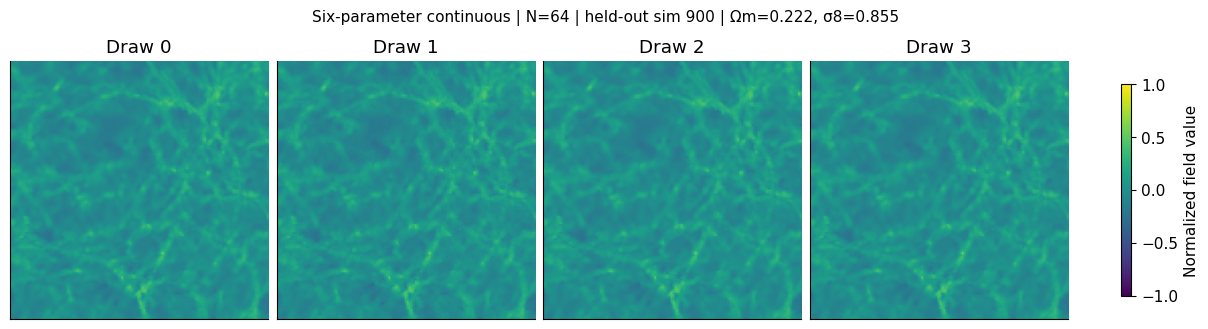

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/samples/nf_cond_bias_hi_u128_d2p06_n64_fresh200k_fullsweep_seed123_dpm50_heldout_k64.npz


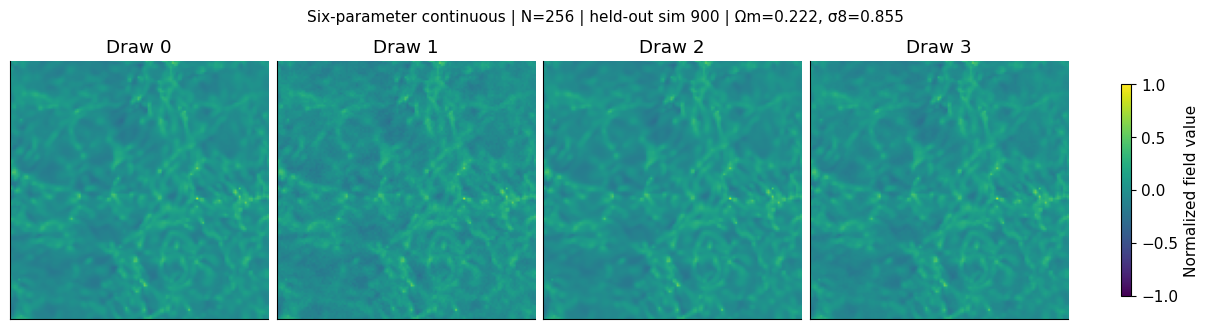

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/samples/nf_cond_bias_hi_u128_d2p08_n256_fresh200k_fullsweep_seed123_dpm50_heldout_k64.npz


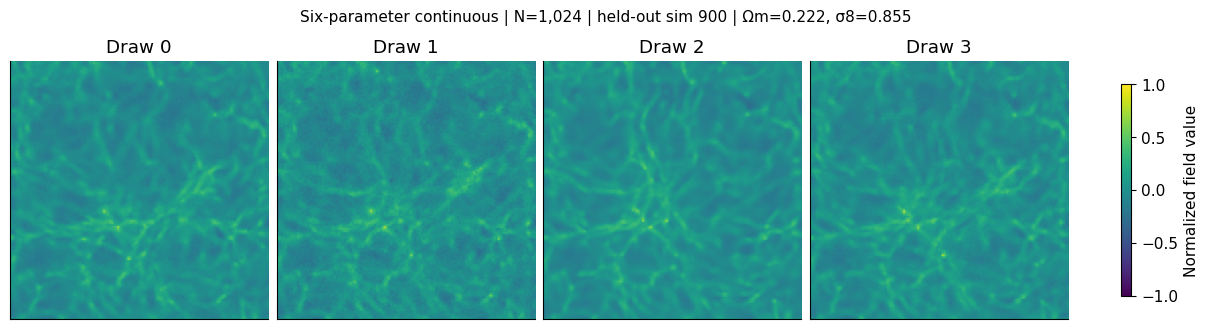

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/samples/nf_cond_bias_hi_u128_d2p10_n1024_fresh200k_fullsweep_seed123_dpm50_heldout_k64.npz


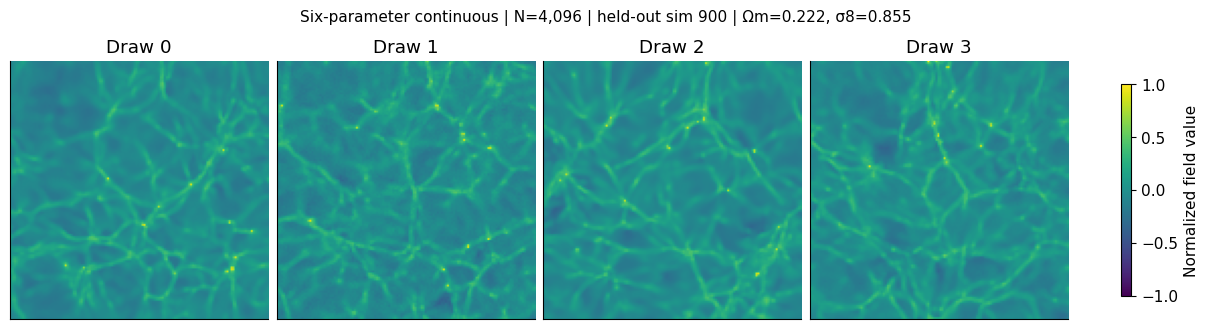

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/samples/nf_cond_bias_hi_u128_d2p12_n4096_fresh200k_fullsweep_seed123_dpm50_heldout_k64.npz


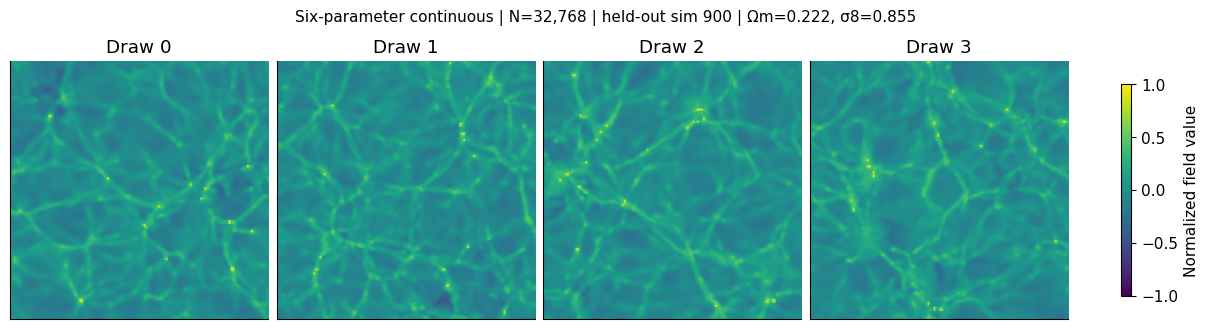

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/samples/nf_cond_bias_hi_u128_d2p15_n32768_fresh200k_fullsweep_seed123_dpm50_heldout_k64.npz

EXPERIMENT: Continuous Ωm–σ8
FOUND: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
FOUND: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/calibration_vgg/bias_probe_eval_metadata.json


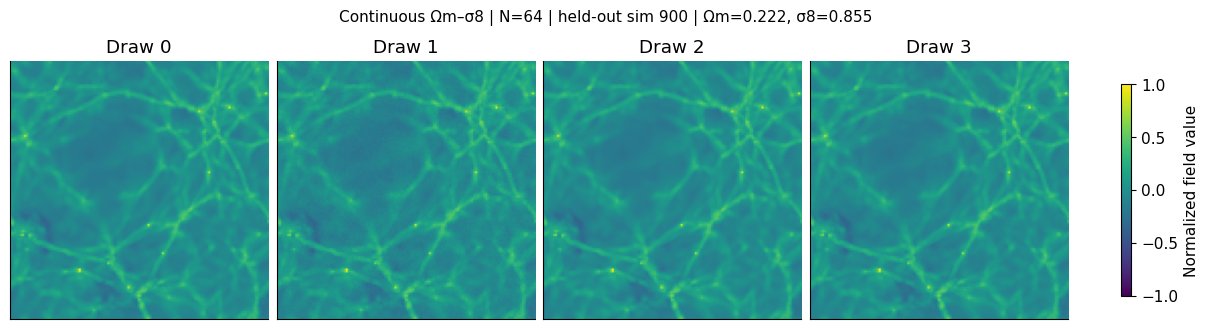

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/samples/nf_cond_omsigc_hi_u128_d2p06_n64_fresh200k_seed123_dpm50_heldout_k64.npz


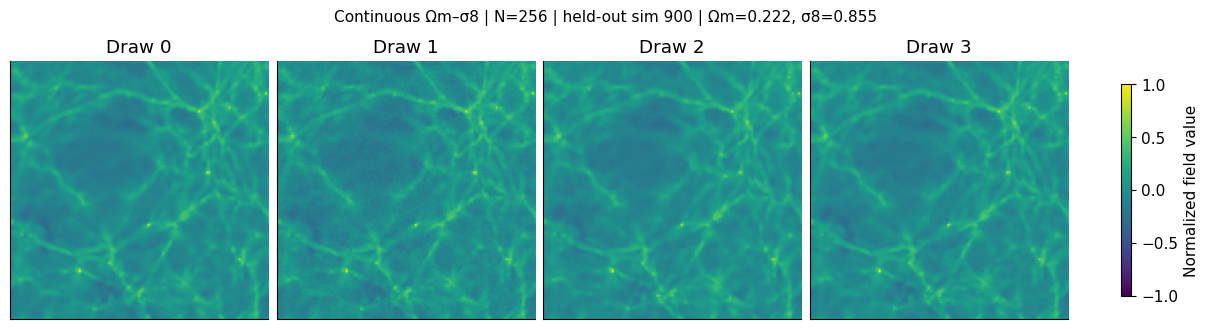

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/samples/nf_cond_omsigc_hi_u128_d2p08_n256_fresh200k_seed123_dpm50_heldout_k64.npz


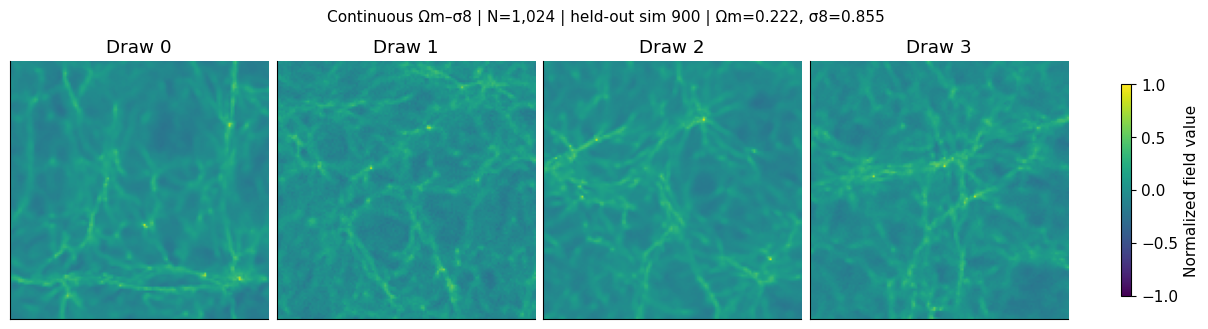

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/samples/nf_cond_omsigc_hi_u128_d2p10_n1024_fresh200k_seed123_dpm50_heldout_k64.npz


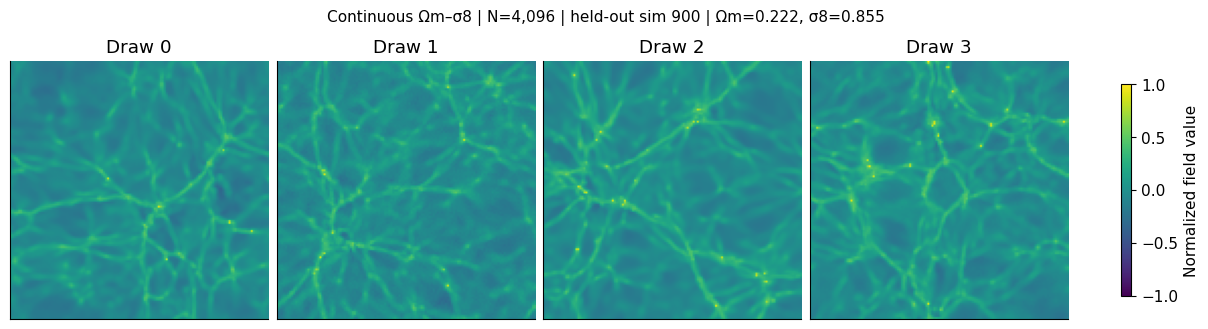

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/samples/nf_cond_omsigc_hi_u128_d2p12_n4096_fresh200k_seed123_dpm50_heldout_k64.npz


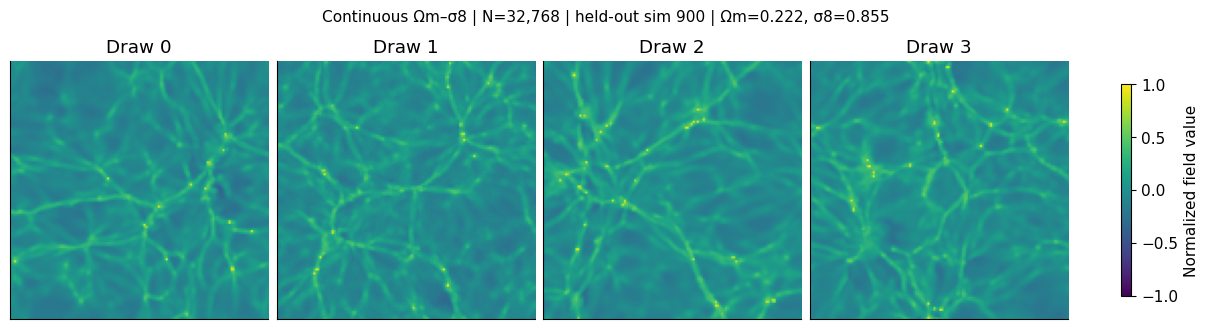

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/samples/nf_cond_omsigc_hi_u128_d2p15_n32768_fresh200k_seed123_dpm50_heldout_k64.npz

EXPERIMENT: 36-class Ωm–σ8
FOUND: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_class36_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
FOUND: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_class36_200k/calibration_vgg/bias_probe_eval_metadata.json


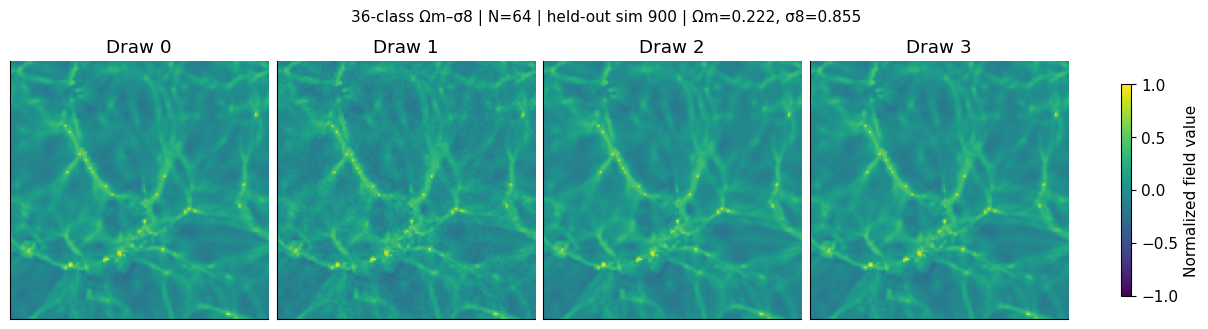

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_class36_200k/samples/nf_cond_omsig36_hi_u128_d2p06_n64_fresh200k_seed123_dpm50_heldout_k64.npz


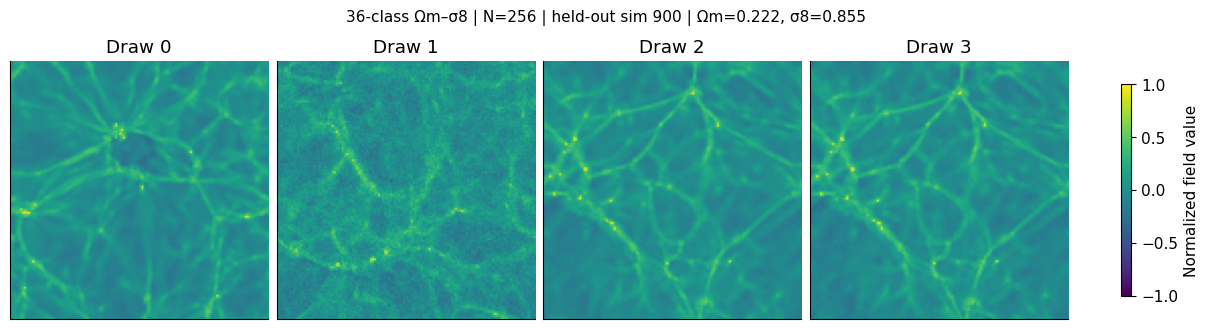

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_class36_200k/samples/nf_cond_omsig36_hi_u128_d2p08_n256_fresh200k_seed123_dpm50_heldout_k64.npz


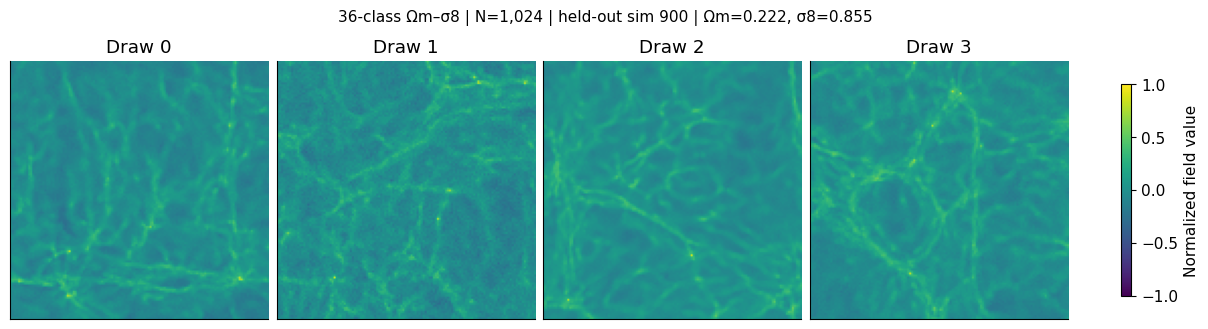

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_class36_200k/samples/nf_cond_omsig36_hi_u128_d2p10_n1024_fresh200k_seed123_dpm50_heldout_k64.npz


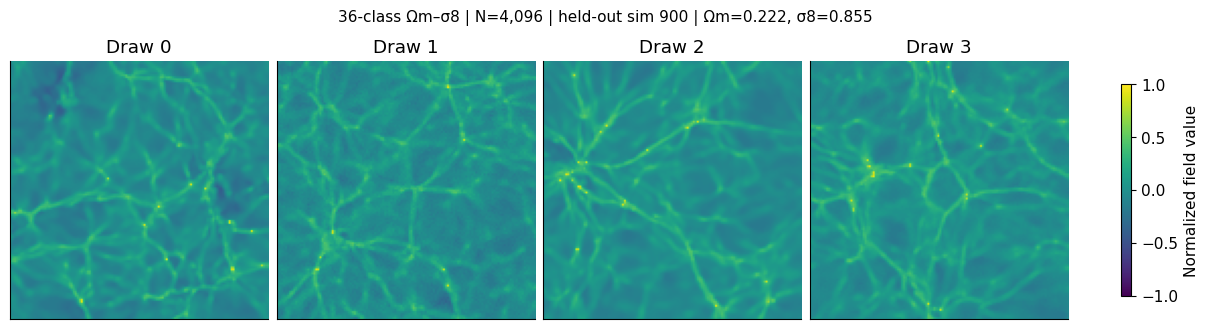

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_class36_200k/samples/nf_cond_omsig36_hi_u128_d2p12_n4096_fresh200k_seed123_dpm50_heldout_k64.npz


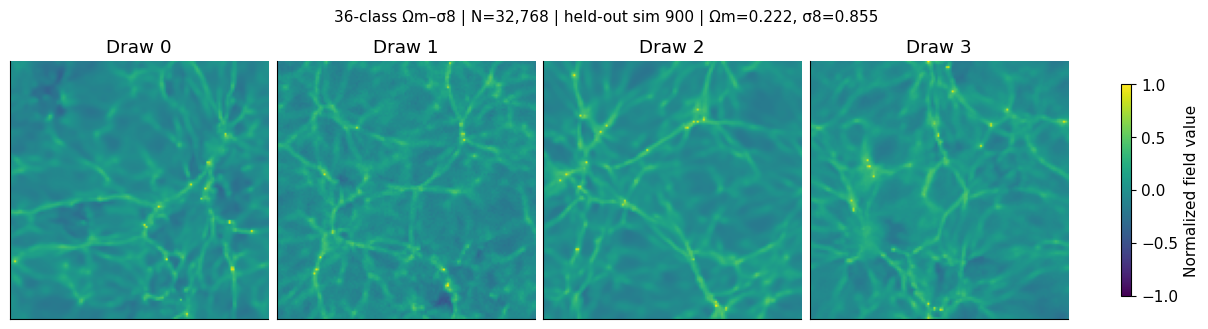

SOURCE: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_class36_200k/samples/nf_cond_omsig36_hi_u128_d2p15_n32768_fresh200k_seed123_dpm50_heldout_k64.npz


,Experiment,N,Sample exists,Source
0,Six-parameter continuous,64,True,/home/jiamingp/diffusion_models_repo/results/n...
1,Six-parameter continuous,256,True,/home/jiamingp/diffusion_models_repo/results/n...
2,Six-parameter continuous,1024,True,/home/jiamingp/diffusion_models_repo/results/n...
3,Six-parameter continuous,4096,True,/home/jiamingp/diffusion_models_repo/results/n...
4,Six-parameter continuous,32768,True,/home/jiamingp/diffusion_models_repo/results/n...
5,Continuous Ωm–σ8,64,True,/home/jiamingp/diffusion_models_repo/results/n...
6,Continuous Ωm–σ8,256,True,/home/jiamingp/diffusion_models_repo/results/n...
7,Continuous Ωm–σ8,1024,True,/home/jiamingp/diffusion_models_repo/results/n...
8,Continuous Ωm–σ8,4096,True,/home/jiamingp/diffusion_models_repo/results/n...
9,Continuous Ωm–σ8,32768,True,/home/jiamingp/diffusion_models_repo/results/n...


In [4]:
sample_inventory = []
for label, sweep in SWEEPS.items():
    manifest = PROJECT_DIR / 'local' / sweep / 'manifest.json'
    folder = PROJECT_DIR / 'results' / sweep / 'calibration_vgg'
    print('\nEXPERIMENT:', label)
    for filename in ['bias_probe_per_cosmology_points.csv','bias_probe_eval_metadata.json']:
        p = folder / filename
        print(('FOUND: ' if p.is_file() else 'MISSING: ') + str(p))
    if not manifest.is_file():
        print('MISSING MANIFEST:', manifest)
        continue
    manifest_rows = json.loads(manifest.read_text())
    assert isinstance(manifest_rows, list), 'Expected a list of runs in ' + str(manifest)
    for row in sorted(manifest_rows, key=lambda r:int(r['dataset_size'])):
        size = int(row['dataset_size'])
        if size not in SIZES: continue
        sample = Path(row['sample_path'].format(seed=123, k=64))
        if not sample.is_absolute(): sample = PROJECT_DIR / sample
        sample_inventory.append({'Experiment':label,'N':size,'Sample exists':sample.is_file(),'Source':str(sample)})
        if not sample.is_file(): continue
        with np.load(sample,allow_pickle=False) as data:
            assert {'samples','theta_raw','heldout_indices','samples_per_cosmology'} <= set(data.files), sample
            k = int(data['samples_per_cosmology'])
            theta = np.asarray(data['theta_raw'])
            ids = np.asarray(data['heldout_indices'])
            array = data['samples']
            assert k == 64 and len(ids) == 32 and len(array) == len(ids)*k, sample
            assert array.shape[1:] == (1,128,128), array.shape
            maps = np.asarray(array[:4,0], dtype=float).copy()
            del array
        assert np.isfinite(maps).all(), sample
        fig, axes = plt.subplots(1,4,figsize=(12,3.4),constrained_layout=True)
        for i,ax in enumerate(axes):
            im=ax.imshow(maps[i],cmap='viridis',vmin=-1,vmax=1)
            ax.set_title('Draw '+str(i)); ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(im,ax=axes,label='Normalized field value',shrink=.7)
        fig.suptitle('{} | N={:,} | held-out sim {} | Ωm={:.3f}, σ8={:.3f}'.format(label,size,int(ids[0]),theta[0,0],theta[0,1]),fontsize=11)
        plt.show()
        print('SOURCE:', sample)
if sample_inventory:
    display(pd.DataFrame(sample_inventory))
else:
    print('No sample manifests found. Verify PROJECT_DIR above; this is not evidence that the remote runs failed.')


In [5]:
# Completeness gate: the analysis counts as complete only if every expected file exists.
inv = pd.DataFrame(inventory); sinv = pd.DataFrame(sample_inventory)
missing_eval = inv[inv.Status != 'Available']
missing_samples = sinv[~sinv['Sample exists']] if not sinv.empty else sinv
expected_samples = len(SWEEPS) * len(SIZES)
ANALYSIS_COMPLETE = missing_eval.empty and len(sinv) == expected_samples and missing_samples.empty \
    and set(points.groupby(['Experiment','dataset_size']).groups) == {(l, n) for l in SWEEPS for n in SIZES}
print(f'Evaluation CSV+metadata available: {int((inv.Status=="Available").sum())}/{len(SWEEPS)}')
print(f'Sample NPZs found: {int(sinv["Sample exists"].sum()) if not sinv.empty else 0}/{expected_samples}')
print('ANALYSIS COMPLETE' if ANALYSIS_COMPLETE else 'ANALYSIS INCOMPLETE — see missing rows above; do not report as final.')


Evaluation CSV+metadata available: 3/3
Sample NPZs found: 15/15
ANALYSIS COMPLETE


## Results
### 1. Accuracy, coverage, and width versus training-set size
Each point summarizes 32 held-out cosmologies. The x-axis is logarithmic. Gaps are missing results, not interpolation. Lines are only visual guides. Quantile ranges describe generated-map spread, not uncertainty in the reported median bias.

,Experiment,N,Parameter,Median bias,Median absolute error,Covered / 32,68% coverage,Median interval width
0,36-class Ωm–σ8,64,Omega_m,-0.0284,0.0565,11,0.3438,0.0601
1,36-class Ωm–σ8,64,sigma_8,-0.0401,0.0771,8,0.2500,0.0674
2,36-class Ωm–σ8,256,Omega_m,-0.0517,0.0517,17,0.5312,0.1123
3,36-class Ωm–σ8,256,sigma_8,0.0052,0.0732,16,0.5000,0.1227
4,36-class Ωm–σ8,1024,Omega_m,-0.0849,0.0849,7,0.2188,0.0965
5,36-class Ωm–σ8,1024,sigma_8,-0.0003,0.0633,12,0.3750,0.1129
6,36-class Ωm–σ8,4096,Omega_m,-0.0232,0.0344,20,0.6250,0.0843
7,36-class Ωm–σ8,4096,sigma_8,-0.0189,0.0508,16,0.5000,0.1133
8,36-class Ωm–σ8,32768,Omega_m,-0.0103,0.0371,20,0.6250,0.0921
9,36-class Ωm–σ8,32768,sigma_8,0.0176,0.0484,18,0.5625,0.1184


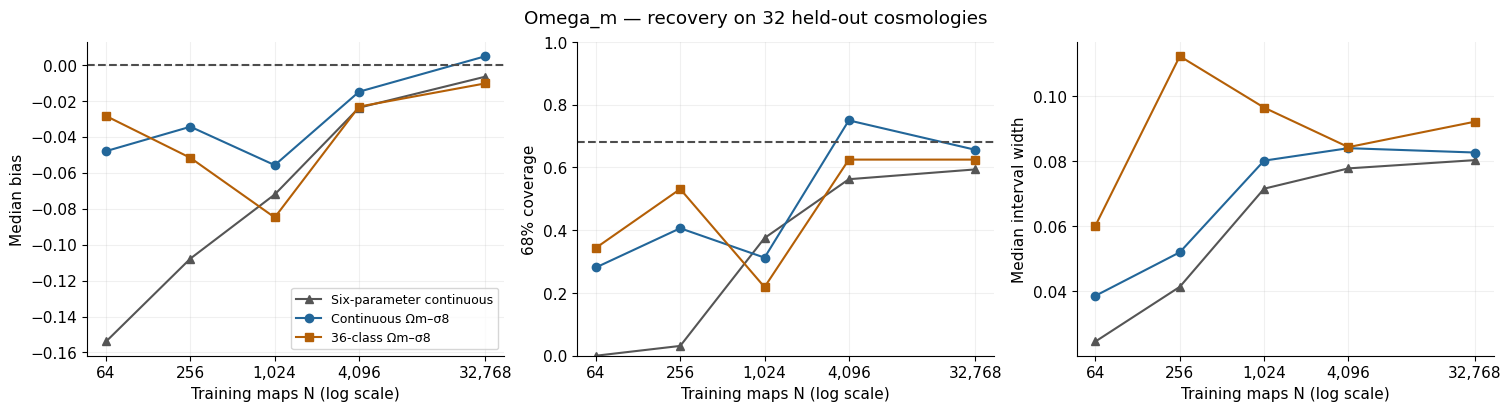

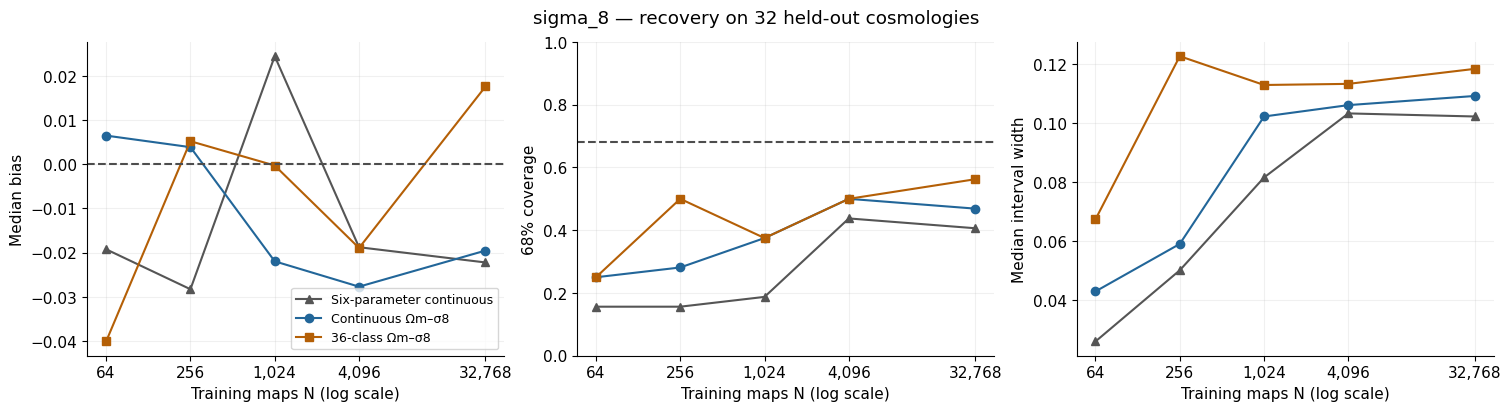

In [6]:
rows = []
if not points.empty:
    for (label, n, parameter), g in points.groupby(['Experiment','dataset_size','parameter']):
        bias = g.theta_rec_median - g.theta_in
        covered = (g.theta_rec_q16 <= g.theta_in) & (g.theta_in <= g.theta_rec_q84)
        rows.append({'Experiment': label, 'N': n, 'Parameter': parameter,
                     'Median bias': bias.median(), 'Median absolute error': bias.abs().median(),
                     'Covered / 32': int(covered.sum()), '68% coverage': covered.mean(),
                     'Median interval width': (g.theta_rec_q84-g.theta_rec_q16).median()})
summary = pd.DataFrame(rows)
if not summary.empty:
    display(summary.round(4))
    for parameter in ['Omega_m', 'sigma_8']:
        fig, axes = plt.subplots(1, 3, figsize=(15,4), constrained_layout=True)
        for label, color, marker in [('Six-parameter continuous','#555555','^'), ('Continuous Ωm–σ8','#226699','o'), ('36-class Ωm–σ8','#b45f06','s')]:
            sub = summary[(summary.Parameter==parameter)&(summary.Experiment==label)].set_index('N').reindex(SIZES)
            for ax, metric in zip(axes, ['Median bias','68% coverage','Median interval width']):
                ax.plot(SIZES, sub[metric], marker=marker, color=color, label=label)
                ax.set_xscale('log', base=2); ax.set_xticks(SIZES)
                ax.set_xticklabels(['64','256','1,024','4,096','32,768'])
                ax.set_xlabel('Training maps N (log scale)'); ax.set_ylabel(metric); ax.grid(alpha=.18)
        axes[0].axhline(0,color='.3',ls='--'); axes[1].axhline(.68,color='.3',ls='--',label='68% reference')
        axes[1].set_ylim(0,1); axes[0].legend(fontsize=9)
        fig.suptitle(parameter + ' — recovery on 32 held-out cosmologies')
        save_figure(fig, f'bias_coverage_width_vs_N_{parameter}'); plt.show()
else:
    print('Bias / coverage / width plots: pending saved evaluation CSVs.')


### 1b. Ωm median bias and 68% coverage — matched-size table
Same CSV columns and filters as the multiplicity table: `parameter == 'Omega_m'`, `guidance_label == 'noguidance'`, `cfg_dropout == 0`, the 32 held-out cosmologies 900–931. **Bias = median over cosmologies of (theta_rec_median − theta_in)**; coverage = fraction with theta_in inside [q16, q84]. `theta_in` is read from each CSV unchanged for every variant, **including 36-class** (true held-out Ωm, not the bin centre). A separately labelled bin-centre diagnostic is in section 2b.

In [7]:
om = points[points.parameter == 'Omega_m']
table_rows = []
for (label, n), g in om.groupby(['Experiment', 'dataset_size']):
    bias = g.theta_rec_median - g.theta_in
    covered = (g.theta_rec_q16 <= g.theta_in) & (g.theta_in <= g.theta_rec_q84)
    table_rows.append({'Experiment': label, 'N': n, 'Run': g.run_name.iloc[0], 'n cosmologies': g.heldout_sim.nunique(),
                       'Median Ωm bias': bias.median(), 'Covered / 32': int(covered.sum()),
                       '68% coverage': covered.mean(), 'Source CSV': g.Source.iloc[0]})
omega_table = pd.DataFrame(table_rows)
omega_table['Experiment'] = pd.Categorical(omega_table.Experiment, list(SWEEPS))
omega_table = omega_table.sort_values(['Experiment', 'N']).reset_index(drop=True)
with pd.option_context('display.max_colwidth', None):
    display(omega_table.round(4))
for d in FIG_DIRS.values():
    omega_table.to_csv(d / 'omega_m_bias_coverage_table.csv', index=False)
print('Filters: parameter == Omega_m, guidance_label == noguidance, cfg_dropout == 0, dataset_size in', SIZES)


,Experiment,N,Run,n cosmologies,Median Ωm bias,Covered / 32,68% coverage,Source CSV
0,Six-parameter continuous,64,nf_cond_bias_hi_u128_d2p06_n64_fresh200k_fullsweep,32,-0.1539,0,0.0000,/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
1,Six-parameter continuous,256,nf_cond_bias_hi_u128_d2p08_n256_fresh200k_fullsweep,32,-0.1077,1,0.0312,/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
2,Six-parameter continuous,1024,nf_cond_bias_hi_u128_d2p10_n1024_fresh200k_fullsweep,32,-0.0721,12,0.3750,/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
3,Six-parameter continuous,4096,nf_cond_bias_hi_u128_d2p12_n4096_fresh200k_fullsweep,32,-0.0238,18,0.5625,/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
4,Six-parameter continuous,32768,nf_cond_bias_hi_u128_d2p15_n32768_fresh200k_fullsweep,32,-0.0065,19,0.5938,/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
5,Continuous Ωm–σ8,64,nf_cond_omsigc_hi_u128_d2p06_n64_fresh200k,32,-0.0480,9,0.2812,/home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
6,Continuous Ωm–σ8,256,nf_cond_omsigc_hi_u128_d2p08_n256_fresh200k,32,-0.0344,13,0.4062,/home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
7,Continuous Ωm–σ8,1024,nf_cond_omsigc_hi_u128_d2p10_n1024_fresh200k,32,-0.0558,10,0.3125,/home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
8,Continuous Ωm–σ8,4096,nf_cond_omsigc_hi_u128_d2p12_n4096_fresh200k,32,-0.0149,24,0.7500,/home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/calibration_vgg/bias_probe_per_cosmology_points.csv
9,Continuous Ωm–σ8,32768,nf_cond_omsigc_hi_u128_d2p15_n32768_fresh200k,32,0.0048,21,0.6562,/home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/calibration_vgg/bias_probe_per_cosmology_points.csv


Filters: parameter == Omega_m, guidance_label == noguidance, cfg_dropout == 0, dataset_size in [64, 256, 1024, 4096, 32768]


### 1c. Ωm median bias versus N — three variants on one panel
Same numbers as table 1b (`theta_in` from each CSV).

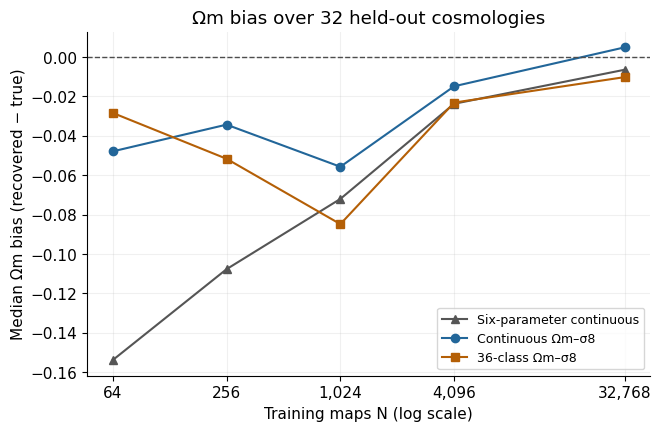

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)
for label, color, marker in [('Six-parameter continuous','#555555','^'), ('Continuous Ωm–σ8','#226699','o'), ('36-class Ωm–σ8','#b45f06','s')]:
    sub = omega_table[omega_table.Experiment == label].set_index('N').reindex(SIZES)
    ax.plot(SIZES, sub['Median Ωm bias'], marker=marker, color=color, label=label)
ax.axhline(0, color='.3', ls='--', lw=1)
ax.set_xscale('log', base=2); ax.set_xticks(SIZES); ax.set_xticklabels(['64','256','1,024','4,096','32,768'])
ax.set_xlabel('Training maps N (log scale)'); ax.set_ylabel('Median Ωm bias (recovered − true)')
ax.set_title('Ωm bias over 32 held-out cosmologies'); ax.grid(alpha=.18); ax.legend(fontsize=9)
save_figure(fig, 'omega_m_bias_vs_N_three_variants'); plt.show()


### 2. Does recovery follow the requested value?
The dashed diagonal means recovered = requested. Vertical bars are the generated 16th–84th percentiles. Points flattened into a horizontal band mean weak response to the requested parameter. For class conditioning, interpret structure in light of shared bins, not as exact-label conditioning.

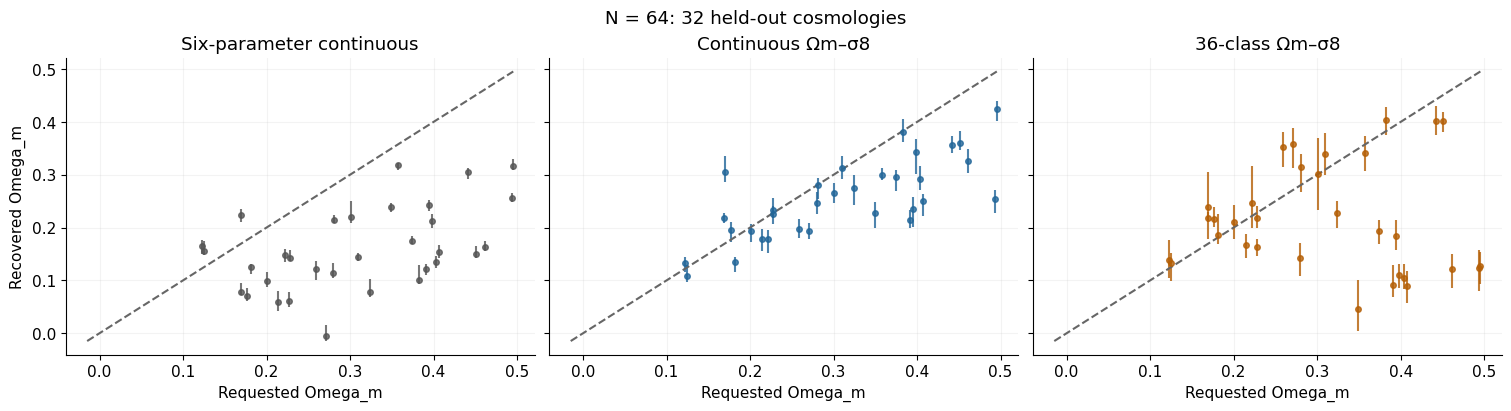

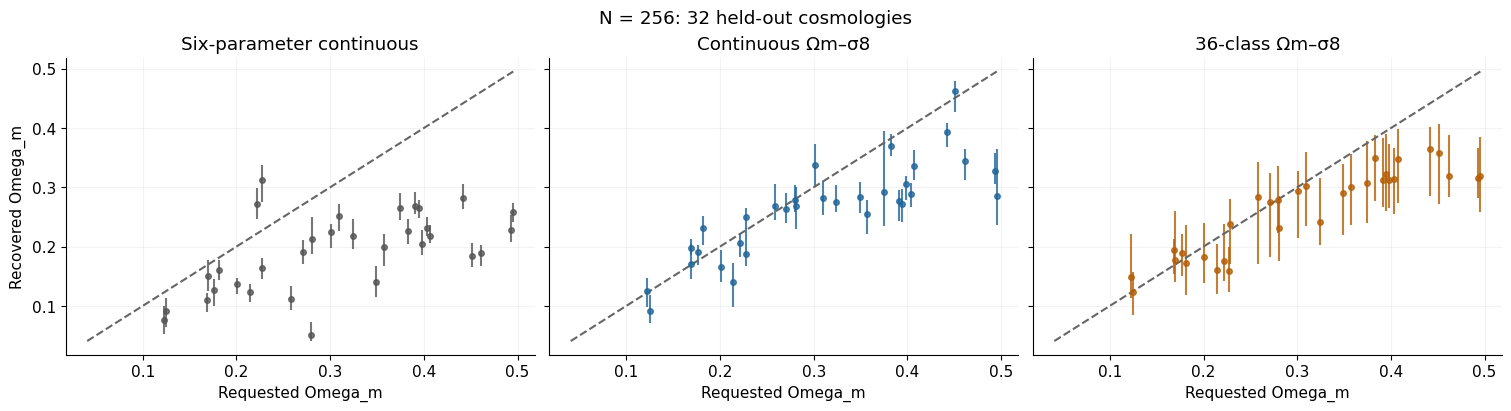

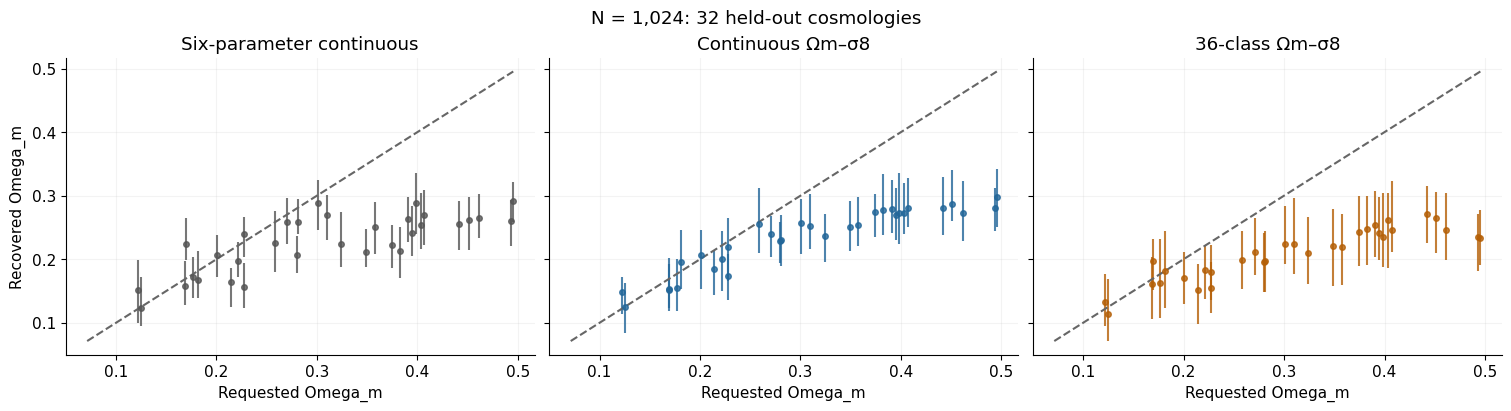

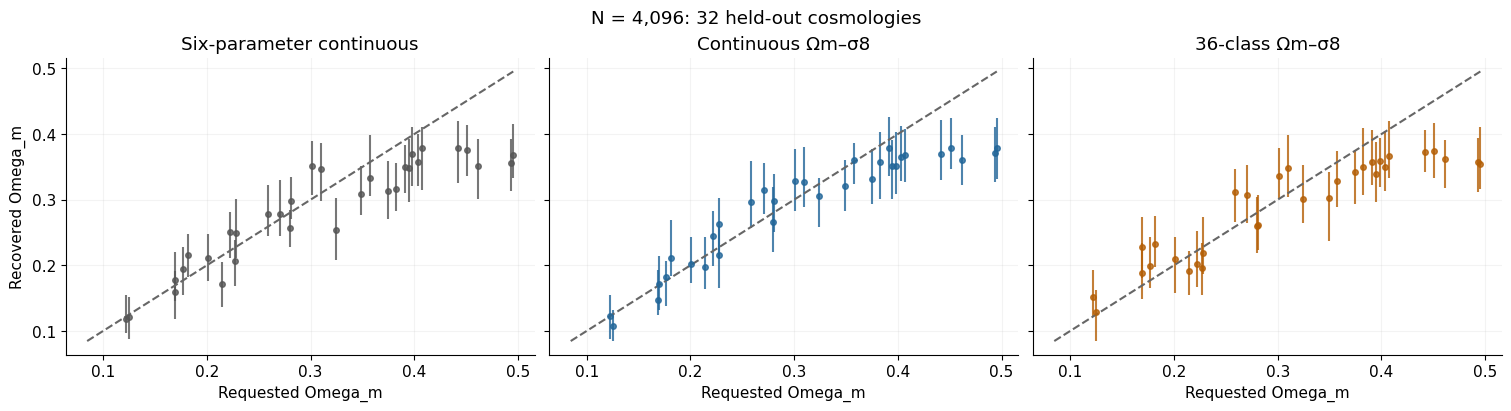

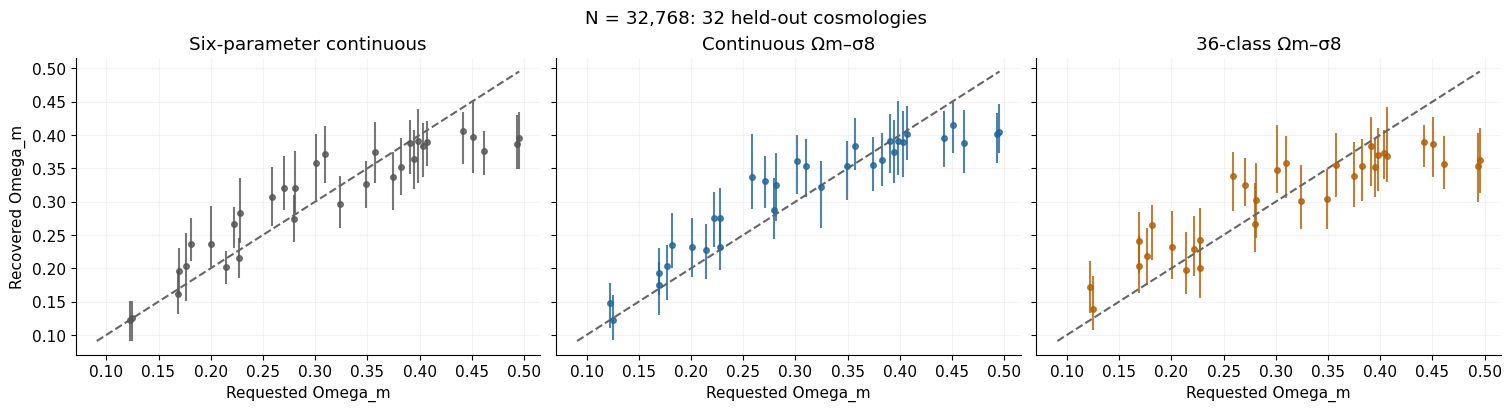

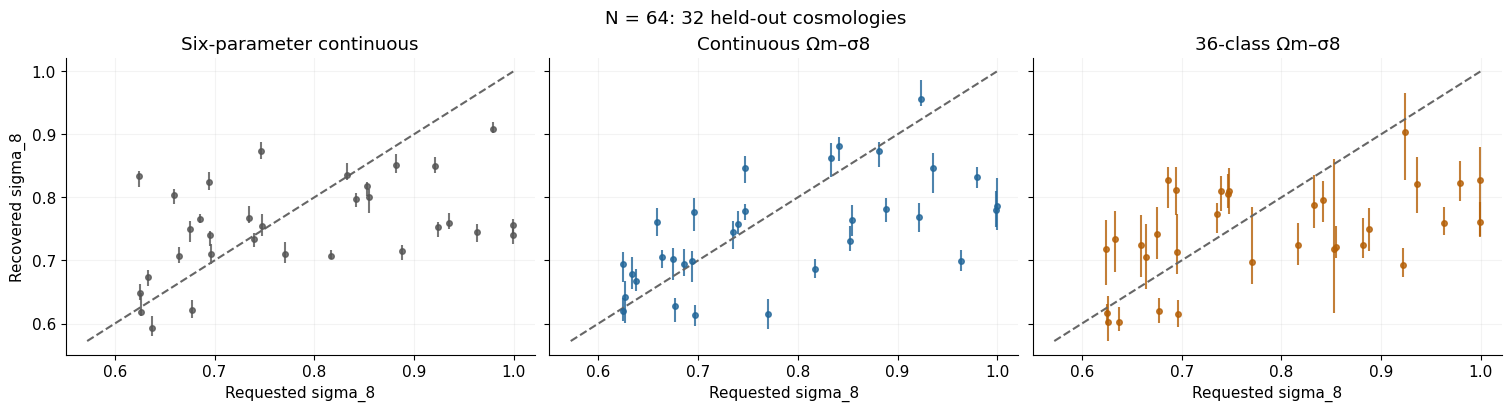

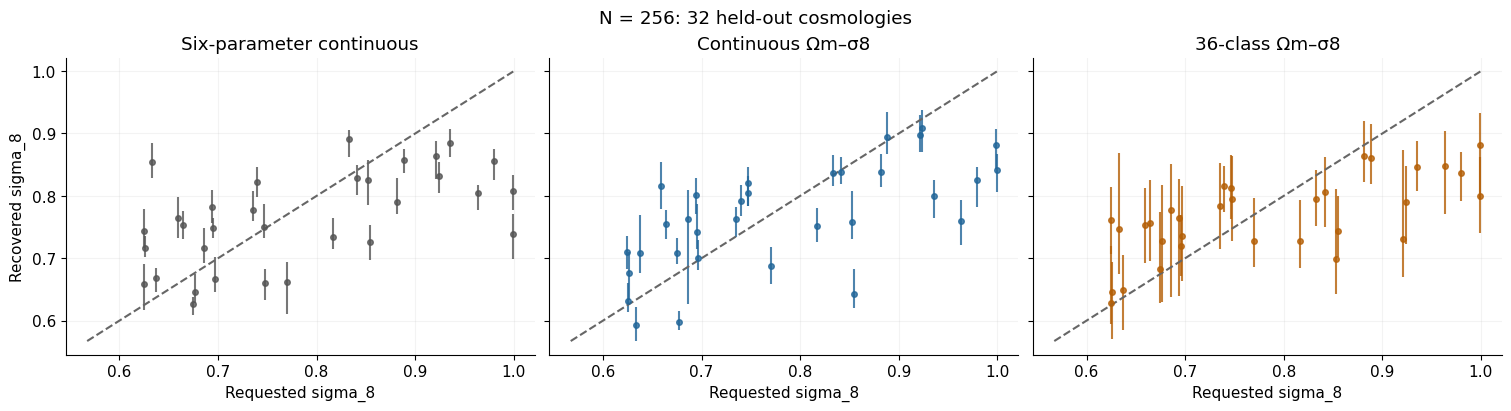

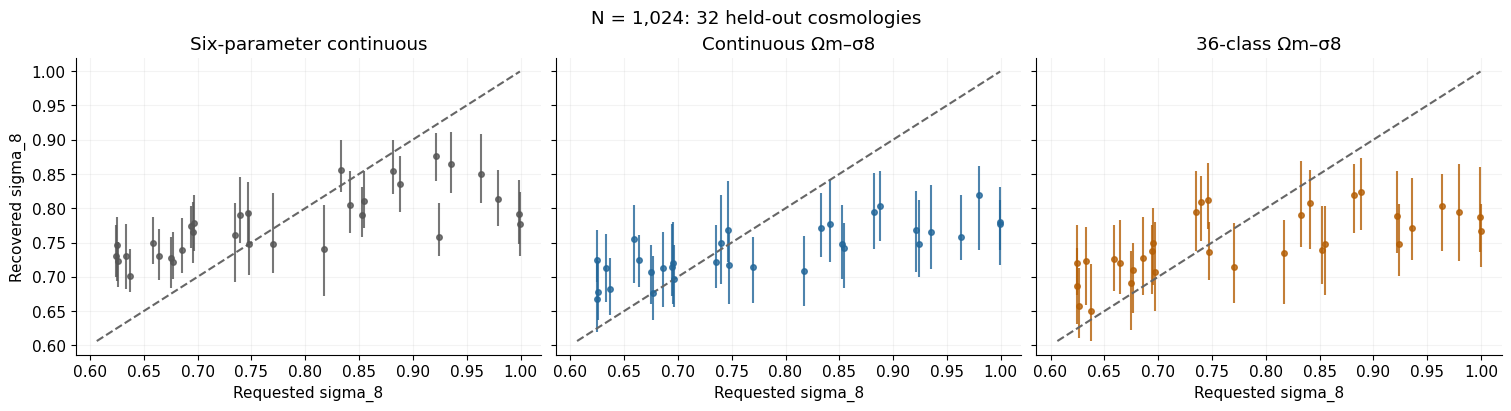

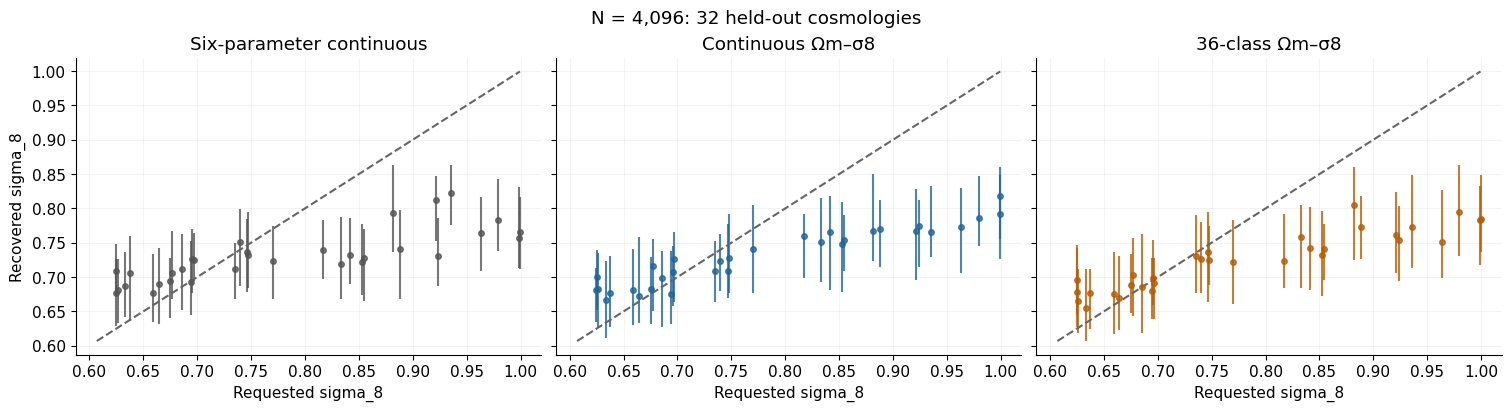

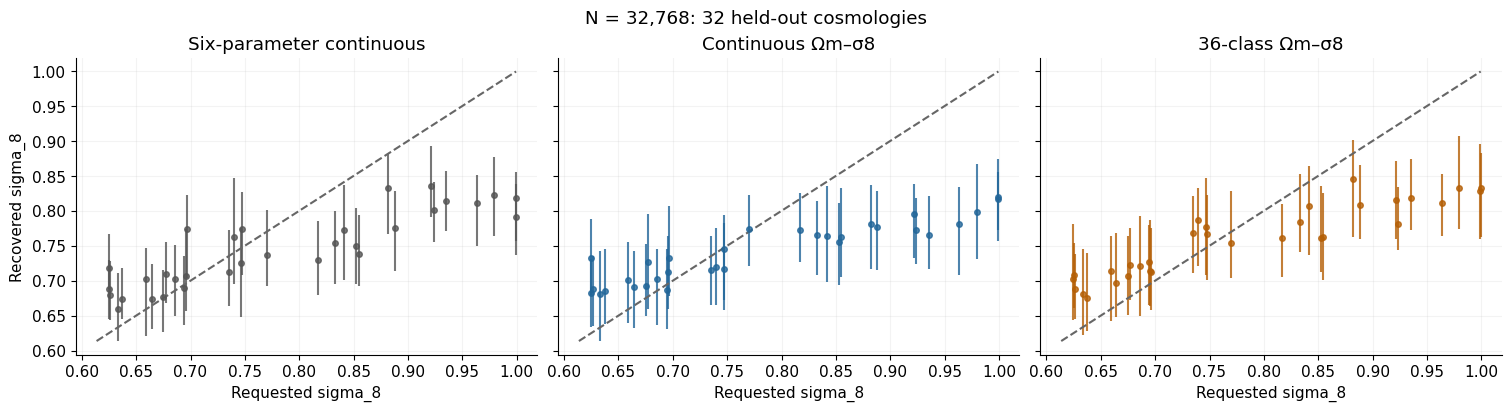

In [9]:
if not points.empty:
    for parameter in ['Omega_m','sigma_8']:
        for n in SIZES:
            subset = points[(points.parameter==parameter)&(points.dataset_size==n)]
            if subset.empty: continue
            fig, axes = plt.subplots(1,3,figsize=(15,4),constrained_layout=True,sharex=True,sharey=True)
            for ax, label, color in zip(axes, SWEEPS, ['#555555','#226699','#b45f06']):
                g = subset[subset.Experiment==label]
                ax.set_title(label); ax.set_xlabel('Requested ' + parameter)
                if g.empty:
                    ax.text(.5,.5,'Not available',ha='center',transform=ax.transAxes); continue
                y = g.theta_rec_median
                ax.errorbar(g.theta_in,y,yerr=[y-g.theta_rec_q16,g.theta_rec_q84-y],fmt='o',ms=4,color=color,alpha=.8)
            lo = min(subset.theta_in.min(),subset.theta_rec_q16.min())
            hi = max(subset.theta_in.max(),subset.theta_rec_q84.max())
            for ax in axes: ax.plot([lo,hi],[lo,hi],'--',color='.4'); ax.grid(alpha=.15)
            axes[0].set_ylabel('Recovered ' + parameter)
            fig.suptitle('N = {:,}: 32 held-out cosmologies'.format(n))
            save_figure(fig, f'one_to_one_{parameter}_N{n}'); plt.show()
else:
    print('Per-cosmology plots: pending saved evaluation CSVs.')


### 2b. 36-class: recovery against the conditioning bin (bin-centre diagnostic)
The class model is asked for a bin, not a point. Here the x-position is the **centre of the conditioning Ωm bin**, with horizontal bars spanning the bin edges; bin edges, class centres and held-out class IDs are read from the saved manifest (`local/nf_conditional_omsig_class36_200k/manifest.json`). Vertical bars are the generated 16–84% range. Open circles keep the original held-out true Ωm (`theta_in`) at the same recovered value. **This view is a diagnostic only; table 1b and plot 1c use `theta_in`.**

Bin edges (Ωm): [0.1    0.1667 0.2333 0.3    0.3667 0.4333 0.5   ] | width 0.0667
Sources:
  /home/jiamingp/diffusion_models_repo/local/nf_conditional_omsig_class36_200k/heldout/class_centers_omsig.npy
  /home/jiamingp/diffusion_models_repo/local/nf_conditional_omsig_class36_200k/heldout/heldout_class_ids.npy


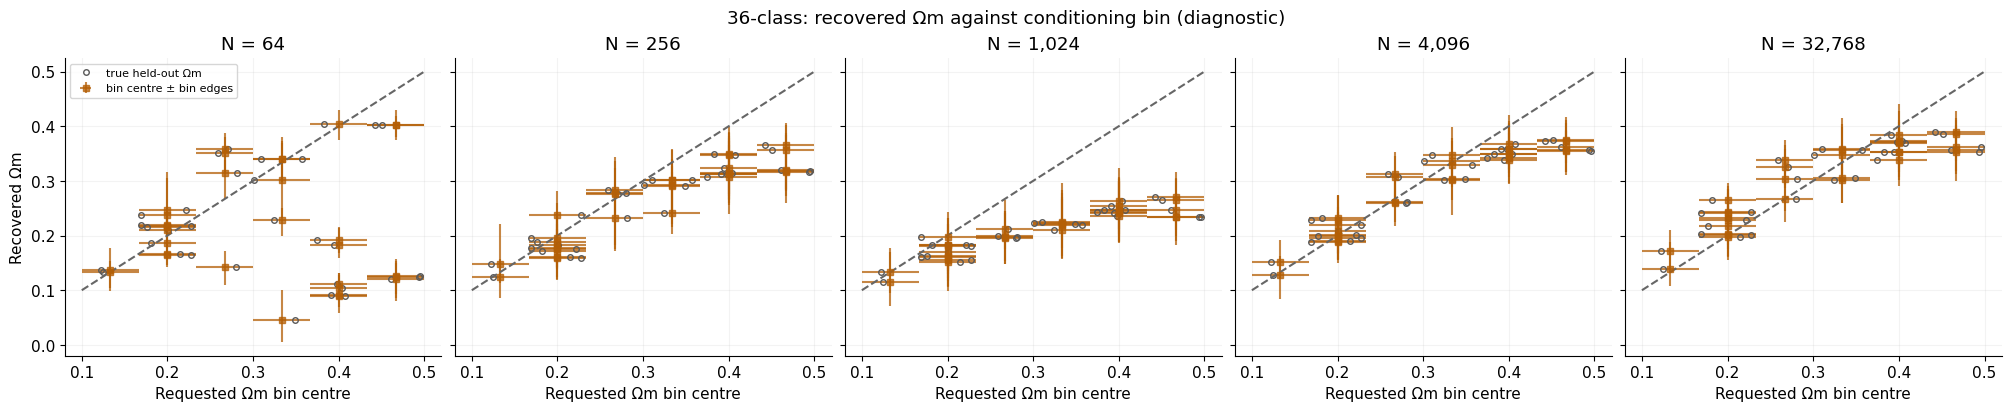

,N,Median bias vs bin centre (diagnostic),Coverage of bin centre (diagnostic)
0,64,-0.0329,0.3125
1,256,-0.0398,0.5312
2,1024,-0.1091,0.2812
3,4096,-0.0082,0.7500
4,32768,0.0008,0.6562


In [10]:
cls_manifest = json.loads((PROJECT_DIR / 'local' / SWEEPS['36-class Ωm–σ8'] / 'manifest.json').read_text())
r0 = cls_manifest[0]
for r in cls_manifest:
    for key in ('omega_bin_edges', 'class_centers_path', 'heldout_class_ids_path', 'heldout_indices_path'):
        assert r[key] == r0[key], ('Bin definition differs between runs', key)
om_edges = np.asarray(r0['omega_bin_edges'], float)
centers = np.load(r0['class_centers_path']); class_ids = np.load(r0['heldout_class_ids_path'])
heldout_ids = np.loadtxt(r0['heldout_indices_path'], dtype=int)
assert centers.shape == (36, 2) and len(class_ids) == len(heldout_ids) == 32
bins = pd.DataFrame({'heldout_sim': heldout_ids, 'class_id': class_ids,
                     'bin_centre_Om': centers[class_ids, 0],
                     'bin_lo_Om': om_edges[class_ids // 6], 'bin_hi_Om': om_edges[class_ids // 6 + 1]})
print('Bin edges (Ωm):', np.round(om_edges, 4), '| width', round(float(np.diff(om_edges)[0]), 4))
print('Sources:', r0['class_centers_path'], r0['heldout_class_ids_path'], sep='\n  ')
cls = om[om.Experiment == '36-class Ωm–σ8'].merge(bins, on='heldout_sim', validate='many_to_one')
assert ((cls.theta_in >= cls.bin_lo_Om - 1e-6) & (cls.theta_in <= cls.bin_hi_Om + 1e-6)).all(), 'True Ωm outside its bin'

fig, axes = plt.subplots(1, len(SIZES), figsize=(4 * len(SIZES), 4), constrained_layout=True, sharex=True, sharey=True)
diag_rows = []
for ax, n in zip(axes, SIZES):
    g = cls[cls.dataset_size == n]
    y = g.theta_rec_median
    ax.errorbar(g.bin_centre_Om, y, xerr=[g.bin_centre_Om - g.bin_lo_Om, g.bin_hi_Om - g.bin_centre_Om],
                yerr=[y - g.theta_rec_q16, g.theta_rec_q84 - y], fmt='s', ms=4, color='#b45f06', alpha=.75, label='bin centre ± bin edges')
    ax.plot(g.theta_in, y, 'o', mfc='none', mec='.35', ms=4, label='true held-out Ωm')
    ax.plot([0.1, 0.5], [0.1, 0.5], '--', color='.4'); ax.grid(alpha=.15)
    ax.set_title(f'N = {n:,}'); ax.set_xlabel('Requested Ωm bin centre')
    covered = (g.theta_rec_q16 <= g.bin_centre_Om) & (g.bin_centre_Om <= g.theta_rec_q84)
    diag_rows.append({'N': n, 'Median bias vs bin centre (diagnostic)': (y - g.bin_centre_Om).median(),
                      'Coverage of bin centre (diagnostic)': covered.mean()})
axes[0].set_ylabel('Recovered Ωm'); axes[0].legend(fontsize=8)
fig.suptitle('36-class: recovered Ωm against conditioning bin (diagnostic)')
save_figure(fig, 'class36_one_to_one_omega_m_bin_centre', labels=['36-class Ωm–σ8']); plt.show()
display(pd.DataFrame(diag_rows).round(4))


### 2c. Draw-to-draw cosine at the held-out parameters
Definition reused from `simdiff_eval/train_theta_report.py` (`within_cosmology_draw_cosine`, also reported for the multiplicity runs): for each held-out cosmology, take its 64 generated maps, subtract each map's own mean, normalise, and average the cosine over all 64·63/2 = 2,016 distinct pairs (`pairwise_centered_cosine_stats(...)['mean']` in `simdiff_eval/conditional_unet_diagnostics.py`). Then summarise over the same 32 held-out cosmologies with `summarize` (median, 16th/84th percentile, mean). Higher values mean less diversity between draws at fixed parameters. Only the existing sample NPZs listed in the Data section are read; nothing is resampled.

,Experiment,N,Median draw cosine,q16,q84,Mean,n cosmologies,Source NPZ
0,Six-parameter continuous,64,0.9964,0.9951,0.9972,0.9962,32,/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/samples/nf_cond_bias_hi_u128_d2p06_n64_fresh200k_fullsweep_seed123_dpm50_heldout_k64.npz
1,Six-parameter continuous,256,0.9829,0.9780,0.9879,0.9829,32,/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/samples/nf_cond_bias_hi_u128_d2p08_n256_fresh200k_fullsweep_seed123_dpm50_heldout_k64.npz
2,Six-parameter continuous,1024,0.8236,0.7324,0.8554,0.8022,32,/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/samples/nf_cond_bias_hi_u128_d2p10_n1024_fresh200k_fullsweep_seed123_dpm50_heldout_k64.npz
3,Six-parameter continuous,4096,0.0811,0.0558,0.1102,0.0812,32,/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/samples/nf_cond_bias_hi_u128_d2p12_n4096_fresh200k_fullsweep_seed123_dpm50_heldout_k64.npz
4,Six-parameter continuous,32768,0.0106,0.0070,0.0180,0.0116,32,/home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/samples/nf_cond_bias_hi_u128_d2p15_n32768_fresh200k_fullsweep_seed123_dpm50_heldout_k64.npz
5,Continuous Ωm–σ8,64,0.9901,0.9843,0.9943,0.9892,32,/home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/samples/nf_cond_omsigc_hi_u128_d2p06_n64_fresh200k_seed123_dpm50_heldout_k64.npz
6,Continuous Ωm–σ8,256,0.9756,0.9042,0.9839,0.9293,32,/home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/samples/nf_cond_omsigc_hi_u128_d2p08_n256_fresh200k_seed123_dpm50_heldout_k64.npz
7,Continuous Ωm–σ8,1024,0.0566,0.0418,0.0744,0.0623,32,/home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/samples/nf_cond_omsigc_hi_u128_d2p10_n1024_fresh200k_seed123_dpm50_heldout_k64.npz
8,Continuous Ωm–σ8,4096,0.0007,0.0002,0.0031,0.0014,32,/home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/samples/nf_cond_omsigc_hi_u128_d2p12_n4096_fresh200k_seed123_dpm50_heldout_k64.npz
9,Continuous Ωm–σ8,32768,0.0003,-0.0005,0.0014,0.0005,32,/home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/samples/nf_cond_omsigc_hi_u128_d2p15_n32768_fresh200k_seed123_dpm50_heldout_k64.npz


Aggregation: per cosmology = mean centred cosine over 2,016 draw pairs; across cosmologies = median (q16–q84) of 32 values.


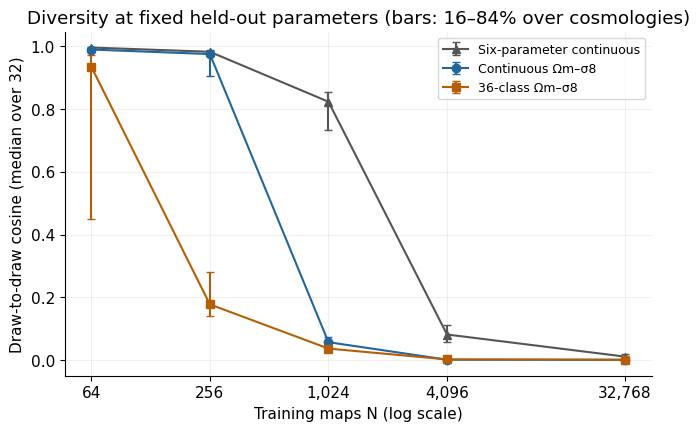

In [11]:
import sys
sys.path.insert(0, str(PROJECT_DIR))
from simdiff_eval.conditional_unet_diagnostics import pairwise_centered_cosine_stats
from simdiff_eval.train_theta_report import summarize
cos_rows, cos_per = [], []
for rec in sample_inventory:
    path = Path(rec['Source']); assert path.is_file(), path
    with np.load(path, allow_pickle=False) as data:
        k = int(data['samples_per_cosmology']); ids = np.asarray(data['heldout_indices'])
        maps = np.asarray(data['samples'][:, 0], dtype=np.float32)
        theta_norm = np.asarray(data['theta_norm_repeated'])
    assert k == 64 and len(ids) == 32 and maps.shape == (32 * k, 128, 128)
    # cosmology-major check: the requested label is constant within each block of k draws
    blocks = theta_norm.reshape(32, k, -1)
    assert np.allclose(blocks, blocks[:, :1]), ('Samples not cosmology-major', path)
    per = [pairwise_centered_cosine_stats(maps[i*k:(i+1)*k])['mean'] for i in range(32)]
    del maps
    s = summarize(per)
    cos_rows.append({'Experiment': rec['Experiment'], 'N': rec['N'], 'Median draw cosine': s['median'],
                     'q16': s['q16'], 'q84': s['q84'], 'Mean': s['mean'], 'n cosmologies': s['n'], 'Source NPZ': str(path)})
    cos_per += [{'Experiment': rec['Experiment'], 'N': rec['N'], 'heldout_sim': int(h), 'draw_cosine': v} for h, v in zip(ids, per)]
cosine_table = pd.DataFrame(cos_rows)
with pd.option_context('display.max_colwidth', None):
    display(cosine_table.round(4))
print('Aggregation: per cosmology = mean centred cosine over 2,016 draw pairs; across cosmologies = median (q16–q84) of 32 values.')
for d in FIG_DIRS.values():
    cosine_table.to_csv(d / 'draw_to_draw_cosine_table.csv', index=False)
    pd.DataFrame(cos_per).to_csv(d / 'draw_to_draw_cosine_per_cosmology.csv', index=False)

fig, ax = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)
for label, color, marker in [('Six-parameter continuous','#555555','^'), ('Continuous Ωm–σ8','#226699','o'), ('36-class Ωm–σ8','#b45f06','s')]:
    sub = cosine_table[cosine_table.Experiment == label].set_index('N').reindex(SIZES)
    ax.errorbar(SIZES, sub['Median draw cosine'], yerr=[sub['Median draw cosine'] - sub.q16, sub.q84 - sub['Median draw cosine']],
                marker=marker, color=color, label=label, capsize=3)
ax.set_xscale('log', base=2); ax.set_xticks(SIZES); ax.set_xticklabels(['64','256','1,024','4,096','32,768'])
ax.set_xlabel('Training maps N (log scale)'); ax.set_ylabel('Draw-to-draw cosine (median over 32)')
ax.set_title('Diversity at fixed held-out parameters (bars: 16–84% over cosmologies)'); ax.grid(alpha=.18); ax.legend(fontsize=9)
save_figure(fig, 'draw_to_draw_cosine_vs_N'); plt.show()


### 3. Paper-style recovery and coverage figure (per variant)
Same layout and definitions as the paper's conditional coverage figure (`build_conditional_coverage_figure` in `scripts/plot_nf_conditional_bias_paper_figures.py`): **left**, recovered vs requested Ωm for three training-set sizes, median and central 68% interval of the 64 per-draw probe recoveries at each of the 32 held-out cosmologies; **right**, empirical coverage of central intervals at 53 nominal levels (0–1 in steps of 0.02, plus 0.68 and 0.95), each the fraction of the 32 cosmologies whose true Ωm lies in the interval. Dashed diagonal = ideal calibration; below = overconfident, above = underconfident; circles / squares mark 68% / 95%.

Source: `bias_probe_per_sample_predictions.csv` (filters `noguidance`, `cfg_dropout == 0`, `Omega_m`). The paper figure used N = 2⁷, 2¹⁰, 2¹⁴; these sweeps only have 2⁶, 2⁸, 2¹⁰, 2¹², 2¹⁵, so the panels use **N = 2⁸, 2¹⁰, 2¹⁵** (2⁶ dropped as too small), and the six-parameter baseline is drawn at the same N for comparison. For 36-class the x-axis is the true held-out Ωm (`theta_in`, as in table 1b), not the bin centre.

Continuous Ωm–σ8 | source: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_continuous_200k/calibration_vgg/bias_probe_per_sample_predictions.csv


nominal,0.68,0.95
dataset_size,,
256,13/32,18/32
1024,10/32,17/32
32768,21/32,30/32


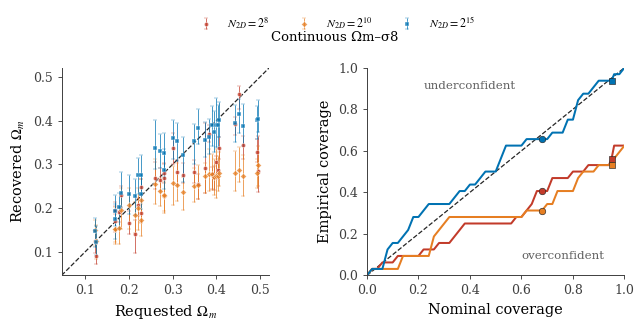

36-class Ωm–σ8 | source: /home/jiamingp/diffusion_models_repo/results/nf_conditional_omsig_class36_200k/calibration_vgg/bias_probe_per_sample_predictions.csv


nominal,0.68,0.95
dataset_size,,
256,17/32,27/32
1024,7/32,16/32
32768,20/32,29/32


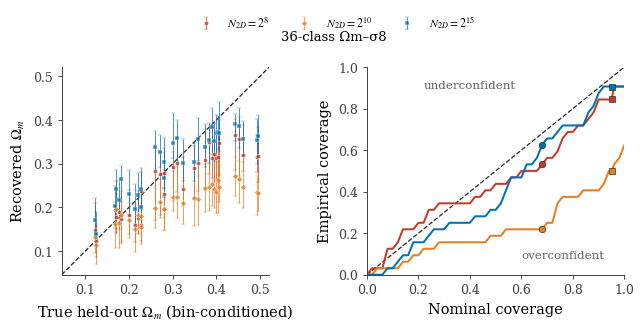

Six-parameter continuous | source: /home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_fresh_full_sweep_200k/calibration_vgg/bias_probe_per_sample_predictions.csv


nominal,0.68,0.95
dataset_size,,
256,1/32,6/32
1024,12/32,14/32
32768,19/32,28/32


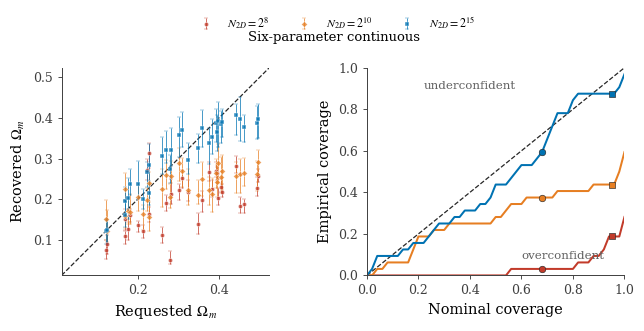

In [12]:
sys.path.insert(0, str(PROJECT_DIR / 'paper' / 'ai4science_verification'))
from paperstyle import FULL_W, set_paper_style, style_axis

COV_POWERS = (8, 10, 15)
COV_STYLES = {8: ('#C23B2A', 'o'), 10: ('#E67E22', 'D'), 15: ('#0072B2', 's')}
COV_FOCAL, COV_MARKERS = (0.68, 0.95), {0.68: 'o', 0.95: 's'}
COV_LEVELS = sorted(set(np.round(np.linspace(0, 1, 51), 10)) | set(COV_FOCAL))

def per_sample_omega(sweep):
    path = PROJECT_DIR / 'results' / sweep / 'calibration_vgg' / 'bias_probe_per_sample_predictions.csv'
    d = pd.read_csv(path)
    d = d[(d.parameter == 'Omega_m') & (d.guidance_label == 'noguidance') & (d.cfg_dropout == 0)
          & d.dataset_size.isin([2**p for p in COV_POWERS])]
    counts = d.groupby(['dataset_size', 'heldout_sim']).size()
    assert (counts == 64).all() and (d.groupby('dataset_size').heldout_sim.nunique() == 32).all(), path
    assert (d.groupby(['dataset_size', 'heldout_sim']).theta_in.nunique() == 1).all()
    return d, path

def coverage_curves(d):
    rows = []
    for (n, sim), g in d.groupby(['dataset_size', 'heldout_sim']):
        truth, draws = g.theta_in.iloc[0], g.theta_rec.to_numpy(float)
        for level in COV_LEVELS:
            lo, hi = np.quantile(draws, [(1 - level) / 2, (1 + level) / 2])
            rows.append({'dataset_size': n, 'nominal': level, 'covered': lo <= truth <= hi})
    return pd.DataFrame(rows).groupby(['dataset_size', 'nominal']).covered.mean().rename('empirical').reset_index()

def coverage_figure(label, sweep):
    d, path = per_sample_omega(sweep)
    rec = d.groupby(['dataset_size', 'heldout_sim']).agg(theta_in=('theta_in', 'first'),
        med=('theta_rec', 'median'), q16=('theta_rec', lambda v: np.quantile(v, .16)),
        q84=('theta_rec', lambda v: np.quantile(v, .84))).reset_index()
    cov = coverage_curves(d)
    with plt.rc_context():
        set_paper_style()
        fig = plt.figure(figsize=(FULL_W, 3.35))
        grid = fig.add_gridspec(1, 2, width_ratios=(1.0, 1.06), left=.10, right=.96, bottom=.18, top=.80, wspace=.32)
        ax_r, ax_c = fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])
        lo, hi = min(rec.theta_in.min(), rec.q16.min()), max(rec.theta_in.max(), rec.q84.max())
        pad = .06 * (hi - lo); lim = (lo - pad, hi + pad)
        ax_r.plot(lim, lim, color='0.15', ls='--', lw=.9, zorder=0)
        handles = []
        for p in COV_POWERS:
            color, marker = COV_STYLES[p]
            s = rec[rec.dataset_size == 2**p].sort_values('theta_in')
            h = ax_r.errorbar(s.theta_in, s.med, yerr=[np.maximum(s.med - s.q16, 0), np.maximum(s.q84 - s.med, 0)],
                              fmt=marker, ms=3, capsize=1.3, elinewidth=.65, color=color, markeredgecolor='white',
                              markeredgewidth=.35, alpha=.78, label=rf'$N_{{2D}}=2^{{{p}}}$')
            handles.append(h)
            c = cov[cov.dataset_size == 2**p]
            ax_c.plot(c.nominal, c.empirical, color=color, lw=1.45)
            for level in COV_FOCAL:
                f = c[np.isclose(c.nominal, level)]
                ax_c.scatter(f.nominal, f.empirical, s=22, marker=COV_MARKERS[level], color=color, edgecolor='0.15', linewidth=.45, zorder=3)
        ax_r.set_xlim(lim); ax_r.set_ylim(lim); ax_r.set_aspect('equal', adjustable='box')
        ax_r.set_xlabel(r'Requested $\Omega_m$' if 'class' not in label else r'True held-out $\Omega_m$ (bin-conditioned)', fontsize=10.5)
        ax_r.set_ylabel(r'Recovered $\Omega_m$', fontsize=10.5)
        ax_c.plot((0, 1), (0, 1), color='0.15', ls='--', lw=.9, zorder=0)
        ax_c.text(.40, .90, 'underconfident', color='0.38', fontsize=8.5, ha='center')
        ax_c.text(.76, .08, 'overconfident', color='0.38', fontsize=8.5, ha='center')
        ax_c.set_xlabel('Nominal coverage', fontsize=10.5); ax_c.set_ylabel('Empirical coverage', fontsize=10.5)
        ax_c.set_xlim(0, 1); ax_c.set_ylim(0, 1); ax_c.set_xticks(np.linspace(0, 1, 6)); ax_c.set_yticks(np.linspace(0, 1, 6))
        for ax in (ax_r, ax_c):
            style_axis(ax); ax.tick_params(labelsize=9)
        fig.legend(handles, [h.get_label() for h in handles], frameon=False, loc='upper center',
                   bbox_to_anchor=(.53, .99), ncol=3, fontsize=8.5)
        fig.text(.53, .88, label, ha='center', fontsize=9.5)
    print(label, '| source:', path)
    focal = cov[cov.nominal.isin(COV_FOCAL)].pivot(index='dataset_size', columns='nominal', values='empirical')
    display((focal * 32).round().astype(int).astype(str) + '/32')
    return fig, cov

coverage_reports = {}
for label, tag, targets in [('Continuous Ωm–σ8', 'continuous', ['Continuous Ωm–σ8']),
                            ('36-class Ωm–σ8', 'class36', ['36-class Ωm–σ8']),
                            ('Six-parameter continuous', 'six_param_baseline', None)]:
    fig, cov = coverage_figure(label, SWEEPS[label])
    save_figure(fig, f'omega_m_recovery_coverage_{tag}', labels=targets)
    for d in (FIG_DIRS[t] for t in (targets or FIG_DIRS)):
        cov.to_csv(d / f'omega_m_coverage_curve_{tag}.csv', index=False)
    coverage_reports[label] = cov
    plt.show()


### 4. Memorization regime: where does the Ωm bias come from? (CPU only, existing samples)
At N ≤ 256 the generated maps are near-copies of training maps (draw cosine ≈ 1). For each generated map we find its **nearest training map** (centred cosine in model space, the space the model was trained in) and split the probe bias into parts. All offsets are **means** over the generated maps, so the parts add up exactly:

* **label offset**: Ωm label of the copied training map − requested Ωm. This asks whether the model copies the *right* training maps.
* **probe-on-copy offset**: probe-recovered Ωm of the generated map − label of the copied map. It splits into:
  * **probe on original**: probe(copied training map) − its label. This is the probe's own error on that real map (section 4b).
  * **copy fidelity**: probe(generated copy) − probe(copied training map). The generated copy reads differently from its original.

Total bias = recovered − requested = label offset + probe on original + copy fidelity (exact for means). Copy threshold: q95 of train-to-train nearest-neighbour cosine with self excluded. The training maps come from distinct simulations, so this threshold is low (≈ 0.17); `nn_cos_median` shows how close the copies actually are. Offsets are also given in units of **W = 0.093**, the 68% width of the same VGG probe on the real held-out maps. No orbit (D4/shift) matching, because these models were trained without augmentation.

The decomposition is meaningful only where the copy fraction is high. At N = 4096 the nearest training map is not a copy, so its label offset is just neighbour scatter: the table keeps that row as a contrast, and the figure leaves it out.

In [13]:
import yaml
from simdiff_eval.io import _normalize_reference_slices
from simdiff_eval.conditional_unet_diagnostics import compare_power

# W: median 68% width of the evaluation probe (vgg_mlp_encoder) on the real held-out maps, 128 slices per cosmology,
# from results/nf_conditional_bias_probe/transform_controls (identity rows). 0.0831 was the other probe (vgg_mlp_big_avgmax).
MEMO_SIZES, W_REAL = (64, 256, 1024, 4096), 0.0931

def train_images_path(row):
    p = row['prepared_image_path']
    return Path(p if p.endswith('.npy') else p + '_images.npy')

def model_space_train_maps(row):
    """Training maps as the model saw them (config log + tanh normalization)."""
    data_cfg = yaml.safe_load((PROJECT_DIR / row['config']).read_text())['data']
    raw = np.asarray(np.load(train_images_path(row), mmap_mode='r')[:, 0], dtype=np.float32)
    return _normalize_reference_slices(raw, data_cfg, data_cfg['norm_kwargs']['center'], data_cfg['norm_kwargs']['xmax'])

def unit_rows(x):
    x = x.reshape(len(x), -1).astype(np.float64); x -= x.mean(1, keepdims=True)
    return (x / np.linalg.norm(x, axis=1, keepdims=True)).astype(np.float32)

def nearest(q, r, exclude_self=False):
    best, idx = np.full(len(q), -2, np.float32), np.zeros(len(q), int)
    for i in range(0, len(r), 1024):
        c = q @ r[i:i + 1024].T
        if exclude_self:
            for j in range(c.shape[1]):
                if i + j < len(q): c[i + j, j] = -2
        a = c.argmax(1); v = c[np.arange(len(q)), a]; m = v > best
        best[m], idx[m] = v[m], a[m] + i
    return best, idx

memo_rows, memo_samples = [], []
for label, sweep in SWEEPS.items():
    manifest = {r['dataset_size']: r for r in json.loads((PROJECT_DIR / 'local' / sweep / 'manifest.json').read_text())}
    pred = pd.read_csv(PROJECT_DIR / 'results' / sweep / 'calibration_vgg' / 'bias_probe_per_sample_predictions.csv')
    pred = pred[(pred.parameter == 'Omega_m') & (pred.guidance_label == 'noguidance') & (pred.cfg_dropout == 0)]
    for n in MEMO_SIZES:
        row = manifest[n]
        train = model_space_train_maps(row); train_om = np.load(row['train_raw_params_path'])[:, 0]
        with np.load(PROJECT_DIR / row['sample_path'].format(seed=123, k=64), allow_pickle=True) as z:
            gen, sims, k, req_c = z['samples'][:, 0], z['heldout_indices'], int(z['samples_per_cosmology']), z['theta_raw'][:, 0]
        keys = list(zip(np.repeat(sims, k), np.tile(np.arange(k), len(sims))))  # samples are cosmology-major
        p = pred[pred.dataset_size == n].set_index(['heldout_sim', 'seed_index']).loc[keys]
        req, rec = np.repeat(req_c, k), p.theta_rec.to_numpy(float)
        assert np.allclose(p.theta_in, req, atol=1e-5), (label, n)
        U_tr, U_gen = unit_rows(train), unit_rows(gen)
        thr = float(np.quantile(nearest(U_tr, U_tr, exclude_self=True)[0], .95))
        cos, j = nearest(U_gen, U_tr)
        pk, _ = compare_power(gen, train)
        memo_samples.append(pd.DataFrame({'model': label, 'dataset_size': n, 'heldout_sim': np.repeat(sims, k), 'seed_index': np.tile(np.arange(k), len(sims)),
                                          'Omega_m_requested': req, 'Omega_m_recovered': rec, 'nn_train_index': j, 'nn_cos': cos,
                                          'is_copy': cos > thr, 'Omega_m_nn_label': train_om[j],
                                          # probe-free copy fidelity: one-point mean/std of copy vs the original training map
                                          'pix_mean_diff': gen.reshape(len(gen), -1).mean(1) - train.reshape(len(train), -1)[j].mean(1),
                                          'pix_std_ratio': gen.reshape(len(gen), -1).std(1) / train.reshape(len(train), -1)[j].std(1)}))
        memo_rows.append({'model': label, 'N': n, 'copy_threshold_q95': thr, 'nn_cos_median': np.median(cos), 'copy_fraction': np.mean(cos > thr),
                          'distinct_train_maps_used': f'{len(np.unique(j))}/{len(train)}',
                          'total_bias': np.mean(rec - req), 'label_offset': np.mean(train_om[j] - req),
                          'probe_on_copy_offset': np.mean(rec - train_om[j]),
                          'pix_mean_diff_median': np.median(memo_samples[-1].pix_mean_diff), 'pix_std_ratio_median': np.median(memo_samples[-1].pix_std_ratio),
                          'pk_ratio_gen_over_train_lowk': pk[:5].mean(), 'pk_ratio_gen_over_train_highk': pk[-8:].mean()})
memo_table = pd.DataFrame(memo_rows)
memo_samples = pd.concat(memo_samples, ignore_index=True)

# Probe reading of the copied training map itself (CPU job scripts/slurm/probe_train_maps_memorization.sbatch).
probe_runs = sorted((PROJECT_DIR / 'results/memorization_regime_diagnostics').glob('probe_on_train_maps_*/probe_on_train_maps.csv'))
if probe_runs:
    pt = pd.read_csv(probe_runs[-1]); print('probe on training maps:', probe_runs[-1])
    memo_samples = memo_samples.merge(pt[['model', 'dataset_size', 'train_index', 'Omega_m_probe']].rename(
        columns={'train_index': 'nn_train_index', 'Omega_m_probe': 'Omega_m_probe_original'}), on=['model', 'dataset_size', 'nn_train_index'], how='left')
    has = memo_samples.Omega_m_probe_original.notna()
    means = memo_samples[has].assign(
        probe_on_original_offset=lambda d: d.Omega_m_probe_original - d.Omega_m_nn_label,   # probe error on the real map
        copy_fidelity_offset=lambda d: d.Omega_m_recovered - d.Omega_m_probe_original     # copy read differently from original
    ).groupby(['model', 'dataset_size'])[['probe_on_original_offset', 'copy_fidelity_offset']].mean()
    memo_table = memo_table.join(means, on=['model', 'N'])
else:
    print('Probe-on-training-maps not run yet: sbatch scripts/slurm/probe_train_maps_memorization.sbatch')
    memo_table['probe_on_original_offset'] = memo_table['copy_fidelity_offset'] = np.nan
for c in ('total_bias', 'label_offset', 'probe_on_copy_offset', 'probe_on_original_offset', 'copy_fidelity_offset'):
    memo_table[c + '_over_W'] = memo_table[c] / W_REAL
for d in FIG_DIRS.values():
    memo_table.to_csv(d / 'memorization_nearest_train_decomposition.csv', index=False)
    memo_samples.to_csv(d / 'memorization_nearest_train_per_sample.csv', index=False)
display(memo_table[['model', 'N', 'nn_cos_median', 'copy_fraction', 'distinct_train_maps_used', 'total_bias_over_W',
                    'label_offset_over_W', 'probe_on_original_offset_over_W', 'copy_fidelity_offset_over_W', 'pix_std_ratio_median']].round(3))

probe on training maps: /home/jiamingp/diffusion_models_repo/results/memorization_regime_diagnostics/probe_on_train_maps_20261003_134050/probe_on_train_maps.csv


,model,N,nn_cos_median,copy_fraction,distinct_train_maps_used,total_bias_over_W,label_offset_over_W,probe_on_original_offset_over_W,copy_fidelity_offset_over_W,pix_std_ratio_median
0,Six-parameter continuous,64,0.608,1.000,25/64,-1.774,-0.243,-0.125,-1.406,0.752
1,Six-parameter continuous,256,0.356,0.984,32/256,-1.397,-0.132,-0.141,-1.124,0.749
2,Six-parameter continuous,1024,0.209,0.350,106/1024,-0.977,-0.058,-0.015,-0.904,0.756
3,Six-parameter continuous,4096,0.159,0.005,1267/4096,-0.306,-0.580,NaN,NaN,0.911
4,Continuous Ωm–σ8,64,0.924,1.000,25/64,-0.663,-0.044,0.022,-0.641,0.897
5,Continuous Ωm–σ8,256,0.951,1.000,38/256,-0.542,0.019,-0.041,-0.520,0.946
6,Continuous Ωm–σ8,1024,0.193,0.279,606/1024,-0.886,-0.266,0.017,-0.637,0.762
7,Continuous Ωm–σ8,4096,0.163,0.007,1319/4096,-0.225,-0.711,NaN,NaN,0.964
8,36-class Ωm–σ8,64,0.983,0.763,34/64,-1.118,-0.575,0.125,-0.668,0.996
9,36-class Ωm–σ8,256,0.966,1.000,129/256,-0.587,0.030,-0.101,-0.516,0.990


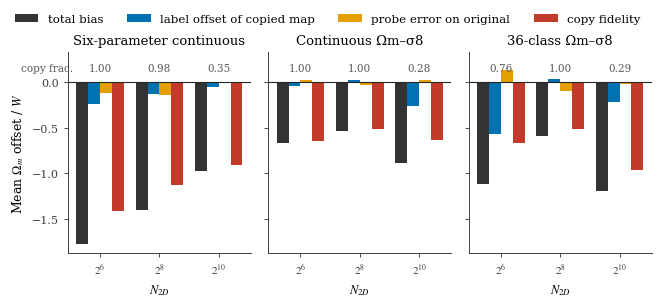

In [14]:
# Decomposition figure (means, in units of W): total = label offset + probe on original + copy fidelity.
with plt.rc_context():
    set_paper_style()
    models = list(SWEEPS)
    fig, axes = plt.subplots(1, len(models), figsize=(FULL_W, 2.9), sharey=True)
    parts = [('total_bias_over_W', 'total bias', '0.2'), ('label_offset_over_W', 'label offset of copied map', '#0072B2'),
             ('probe_on_original_offset_over_W', 'probe error on original', '#E69F00'),
             ('copy_fidelity_offset_over_W', 'copy fidelity', '#C23B2A')]
    if memo_table.copy_fidelity_offset.isna().all():  # probe-on-training-maps not run yet
        parts = parts[:2] + [('probe_on_copy_offset_over_W', 'probe-on-copy offset', '#C23B2A')]
    bw = .8 / len(parts)
    FIG_SIZES = (64, 256, 1024)  # N = 4096 has ~0 copies: the nearest map is not a copy there, so no decomposition
    x = np.arange(len(FIG_SIZES))
    for ax, m in zip(axes, models):
        t = memo_table[memo_table.model == m].set_index('N').loc[list(FIG_SIZES)]
        for i, (col, lab, color) in enumerate(parts):
            ax.bar(x + (i - (len(parts) - 1) / 2) * bw, t[col], bw, color=color, label=lab)
        for xi, cf in zip(x, t.copy_fraction):
            ax.text(xi, .12, f'{cf:.2f}', ha='center', fontsize=7.5, color='0.35')
        ax.axhline(0, color='0.15', lw=.8); ax.set_xticks(x, [rf'$2^{{{int(np.log2(n))}}}$' for n in FIG_SIZES])
        ax.set_title(m, fontsize=9.5); ax.set_xlabel(r'$N_{2D}$'); style_axis(ax)
        ax.set_ylim(top=.32)
    axes[0].set_ylabel(r'Mean $\Omega_m$ offset / $W$')
    axes[0].text(-.45, .12, 'copy frac.', fontsize=7.5, color='0.35', ha='right')
    fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, loc='upper center', ncol=len(parts), fontsize=8.5, bbox_to_anchor=(.5, 1.06))
    fig.tight_layout()
save_figure(fig, 'memorization_bias_decomposition')
plt.show()

#### 4b. Probe controls: can the probe alone produce the bias?
* **Existing control** (`results/nf_conditional_bias_probe/degradation_controls/`, six-parameter models): real held-out maps degraded to match the generated maps' P(k) deficit, then probed. If those degraded real maps show the same bias as the generated maps, the two-point power deficit explains it.
* **Probe on the training maps themselves** (`scripts/probe_train_maps_memorization.py`, CPU job): probe(training map) − label. Near zero means the probe reads these maps correctly, so the probe-on-copy offset comes from imperfect copies. A negative value equal to the probe-on-copy offset means the probe misreads these particular maps.

In [15]:
deg = json.loads((PROJECT_DIR / 'results/nf_conditional_bias_probe/degradation_controls/probe_degradation_metrics.json').read_text())['metrics']
deg = pd.DataFrame([r for r in deg if r['parameter'] == 'Omega_m' and r['grain'] == 'per_cosmology'])
deg['N'] = deg.dataset_size.astype('Int64')
display(deg[['N', 'source', 'bias', 'bias_ci_low', 'bias_ci_high']].sort_values(['N', 'source']).round(4))
print('source: results/nf_conditional_bias_probe/degradation_controls/probe_degradation_metrics.json')

if not probe_runs:
    print('Probe-on-training-maps not run yet: sbatch scripts/slurm/probe_train_maps_memorization.sbatch')
else:
    print('source:', probe_runs[-1])
    pt['probe_minus_label'] = pt.Omega_m_probe - pt.Omega_m_label
    s = memo_samples[memo_samples.Omega_m_probe_original.notna()].copy()
    s['probe_on_copy_offset'] = s.Omega_m_recovered - s.Omega_m_nn_label
    s['probe_train_minus_label'] = s.Omega_m_probe_original - s.Omega_m_nn_label   # probe error on the copied real map
    s['copy_fidelity_offset'] = s.Omega_m_recovered - s.Omega_m_probe_original     # copy read differently from its original
    probe_split = s.groupby(['model', 'dataset_size']).agg(  # means: probe_on_copy = probe_train_minus_label + copy_fidelity
        n_maps=('seed_index', 'size'), probe_on_copy_offset=('probe_on_copy_offset', 'mean'),
        probe_train_minus_label=('probe_train_minus_label', 'mean'), copy_fidelity_offset=('copy_fidelity_offset', 'mean')).reset_index()
    probe_split['all_train_maps_probe_minus_label'] = probe_split.apply(
        lambda r: pt[(pt.model == r.model) & (pt.dataset_size == r.dataset_size)].probe_minus_label.mean(), axis=1)
    for d in FIG_DIRS.values():
        probe_split.to_csv(d / 'memorization_probe_on_train_split.csv', index=False)
    display((probe_split.set_index(['model', 'dataset_size']) / W_REAL).drop(columns='n_maps').round(2).rename(columns=lambda c: c + ' / W'))

,N,source,bias,bias_ci_low,bias_ci_high
2,128,generated,-0.0791,-0.1040,-0.0564
0,128,real_gaussian,-0.0075,-0.0153,0.0003
5,128,real_measured_transfer,-0.0055,-0.0129,0.0027
3,16384,generated,0.0008,-0.0084,0.0105
1,16384,real_gaussian,-0.0006,-0.0081,0.0073
6,16384,real_measured_transfer,0.0040,-0.0041,0.0111
4,<NA>,real_original,-0.0006,-0.0079,0.0066


source: results/nf_conditional_bias_probe/degradation_controls/probe_degradation_metrics.json
source: /home/jiamingp/diffusion_models_repo/results/memorization_regime_diagnostics/probe_on_train_maps_20261003_134050/probe_on_train_maps.csv


probe_on_copy_offset / W  \
model                    dataset_size                             
36-class Ωm–σ8           64                               -0.54   
                         256                              -0.62   
                         1024                             -0.98   
Continuous Ωm–σ8         64                               -0.62   
                         256                              -0.56   
                         1024                             -0.62   
Six-parameter continuous 64                               -1.53   
                         256                              -1.26   
                         1024                             -0.92   

                                       probe_train_minus_label / W  \
model                    dataset_size                                
36-class Ωm–σ8           64                                   0.13   
                         256                                 -0.10   
                         1024                                -0.02   
Continuous Ωm–σ8         64                                   0.02   
                         256                                 -0.04   
                         1024                                 0.02   
Six-parameter continuous 64                                  -0.12   
                         256                                 -0.14   
                         1024                                -0.01   

                                       copy_fidelity_offset / W  \
model                    dataset_size                             
36-class Ωm–σ8           64                               -0.67   
                         256                              -0.52   
                         1024                             -0.96   
Continuous Ωm–σ8         64                               -0.64   
                         256                              -0.52   
                         1024                             -0.64   
Six-parameter continuous 64                               -1.41   
                         256                              -1.12   
                         1024                             -0.90   

                                       all_train_maps_probe_minus_label / W  
model                    dataset_size                                        
36-class Ωm–σ8           64                                            0.10  
                         256                                          -0.02  
                         1024                                         -0.02  
Continuous Ωm–σ8         64                                            0.10  
                         256                                          -0.02  
                         1024                                         -0.02  
Six-parameter continuous 64                                            0.10  
                         256                                          -0.02  
                         1024                                         -0.02

#### 4c. Faithful vs smoothed copies
Copies are split by their pixel-std ratio to the original training map: **faithful** (≥ 0.97) or **smoothed** (< 0.90). If degradation causes the bias, faithful copies should read unbiased relative to the probe on the original, and smoothed copies should read low. Offsets are probe(copy) − probe(original), in units of W. Spearman ρ is computed between the std ratio and that offset.

In [16]:
from scipy.stats import spearmanr
if probe_runs:
    rows = []
    for (m, n), g in s[s.dataset_size.isin([64, 256])].groupby(['model', 'dataset_size']):
        faithful, smoothed = g[g.pix_std_ratio >= .97], g[g.pix_std_ratio < .90]
        rows.append({'model': m, 'N': n, 'frac_smoothed': len(smoothed) / len(g), 'frac_faithful': len(faithful) / len(g),
                     'offset_faithful_over_W': faithful.copy_fidelity_offset.median() / W_REAL if len(faithful) else np.nan,
                     'offset_smoothed_over_W': smoothed.copy_fidelity_offset.median() / W_REAL if len(smoothed) else np.nan,
                     'spearman_std_ratio_vs_offset': spearmanr(g.pix_std_ratio, g.copy_fidelity_offset).correlation})
    copy_quality = pd.DataFrame(rows)
    for d in FIG_DIRS.values():
        copy_quality.to_csv(d / 'memorization_copy_quality_split.csv', index=False)
    display(copy_quality.round(2))

,model,N,frac_smoothed,frac_faithful,offset_faithful_over_W,offset_smoothed_over_W,spearman_std_ratio_vs_offset
0,36-class Ωm–σ8,64,0.34,0.66,-0.08,-1.41,0.59
1,36-class Ωm–σ8,256,0.02,0.82,-0.41,-1.64,0.09
2,Continuous Ωm–σ8,64,0.51,0.17,0.10,-1.06,0.52
3,Continuous Ωm–σ8,256,0.20,0.33,-0.10,-0.86,0.46
4,Six-parameter continuous,64,0.97,0.00,NaN,-1.52,0.50
5,Six-parameter continuous,256,1.00,0.00,NaN,-1.35,0.15


## Takeaways
**Status:** all evaluations are COMPLETED and the files are validated in the Data section (see the completeness gate). Read accuracy, coverage and width together. Lower absolute bias with unchanged or narrower intervals is stronger evidence than higher coverage alone. Inspect both Ωm and σ8 and all sizes, not one favorable point. A single training seed cannot establish a universal generalization law.

**Still outside this notebook:** nearest-training matches, PCA95 novelty, one-point distributions and P(k). These need verified saved samples and matching real maps. No such metric is inferred from recovery slopes or job completion. The six-parameter baseline is read from its original saved CSVs, with recorded evaluation compatibility checks; it is not copied from the multiplicity or blend experiment. Class-bin and exact-label targets remain different even then.

### Where the results are
Under each sweep's `results/<sweep>/calibration_vgg/`: `bias_probe_per_cosmology_points.csv`, `bias_probe_regime_slopes.csv`, and `bias_probe_eval_metadata.json`.

To refresh on Great Lakes after the notebook is uploaded, set PROJECT_DIR if needed and use **Run All** in an existing notebook session. It reads the existing CSVs plus the 15 saved sample NPZs (≈134 MB each) for the draw cosine, so run it on a compute node; no GPU is needed. Figures go to a new `results/nf_conditional_omsig_*/figures/label_sweeps_review_<timestamp>/` folder. Save a new executed copy rather than overwrite older results.